In [1]:
from srcv2.utils import get_data_env
from srcv2.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from srcv2.models import PersistenceModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 2
horizon_leadtime= 3
sequence_length = 1
lags            = 1

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lags                = lags,
    nuts_level          = nuts_level,
    log_transform       = True,
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest
    )    

dataorchestrator    = (DataOrchestrator(config).build())

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

shallowdata        = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('boolean_neighbors_self').construct_dataloaders()
graphdataloader_gr1 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('gravity1').construct_dataloaders()
graphdataloader_cm1 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('commuter1').construct_dataloaders()
graphdataloader_gr2 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('gravity4').construct_dataloaders()
graphdataloader_cm2 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('commuter4').construct_dataloaders()


In [3]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

PersistenceModel(name='Persistence Model')

## RF

In [4]:
rf = NodeRFModel(shallowdata)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=100)
rf.train(verbose=2)
rf.forecast('test')

Training loss for horizon 0: RMSE = 0.6200, MAE = 0.2463
Validation loss for horizon 0: RMSE = 0.8374, MAE = 0.3672
Training loss for horizon 1: RMSE = 0.6928, MAE = 0.2795
Validation loss for horizon 1: RMSE = 0.9616, MAE = 0.4173


NodeRFModel(name='NodeRFModel')

## LSTM


==                     lstm                     ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7064, val loss: 1.0943 ✓ (new best)
Epoch 2 train loss: 0.6744, val loss: 1.0809 ✓ (new best)
Epoch 3 train loss: 0.6802, val loss: 0.9739 ✓ (new best)
Epoch 4 train loss: 0.6603, val loss: 0.9436 ✓ (new best)
Epoch 5 train loss: 0.6563, val loss: 0.8494 ✓ (new best)
Epoch 6 train loss: 0.6491, val loss: 0.8281 ✓ (new best)
Epoch 7 train loss: 0.6390, val loss: 0.7793 ✓ (new best)
Epoch 8 train loss: 0.6367, val loss: 0.7778 ✓ (new best)
Epoch 9 train loss: 0.6270, val loss: 0.7808 (patience: 1/20)
Epoch 10 train loss: 0.6194, val loss: 0.7848 (patience: 2/20)
Epoch 11 train loss: 0.6113, val loss: 0.7848 (patience: 3/20)
Epoch 12 train loss: 0.5998, val loss: 0.7817 (patience: 4/20)
Epoch 13 train loss: 0.5898, val loss: 0.7766 ✓ (new best)
Epoch 14 train loss: 0.5777, val loss: 0.7615 ✓ (new best)
Epoch 15 train l

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 577.40it/s]

Test loss: 0.8208


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

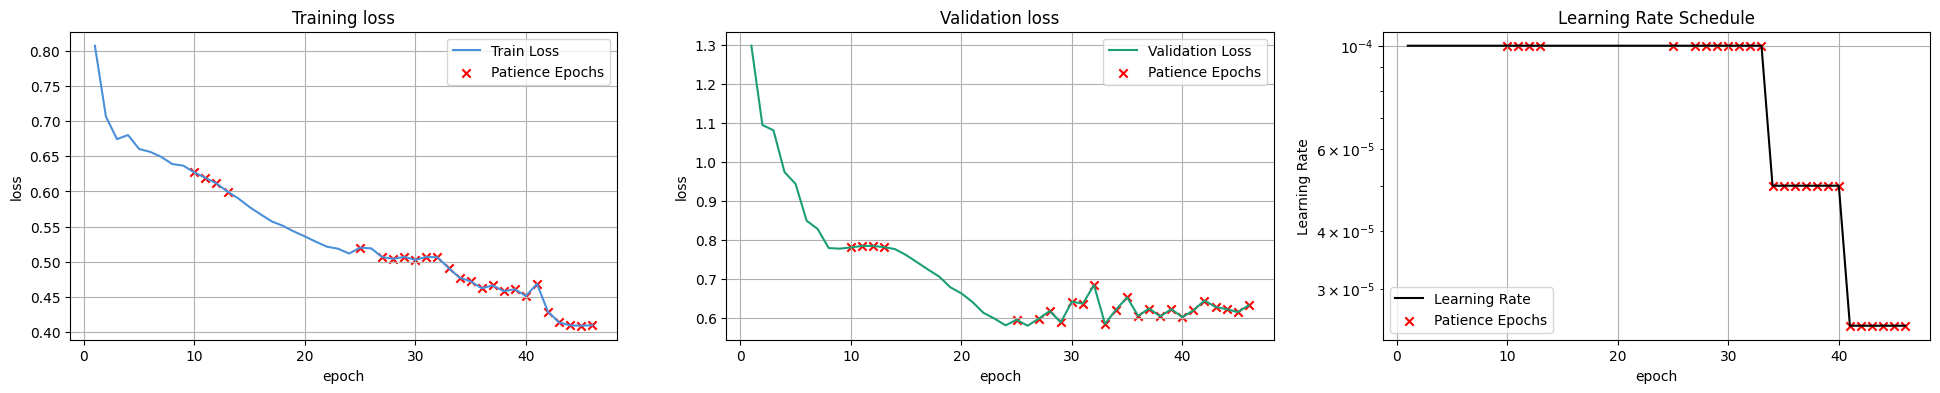

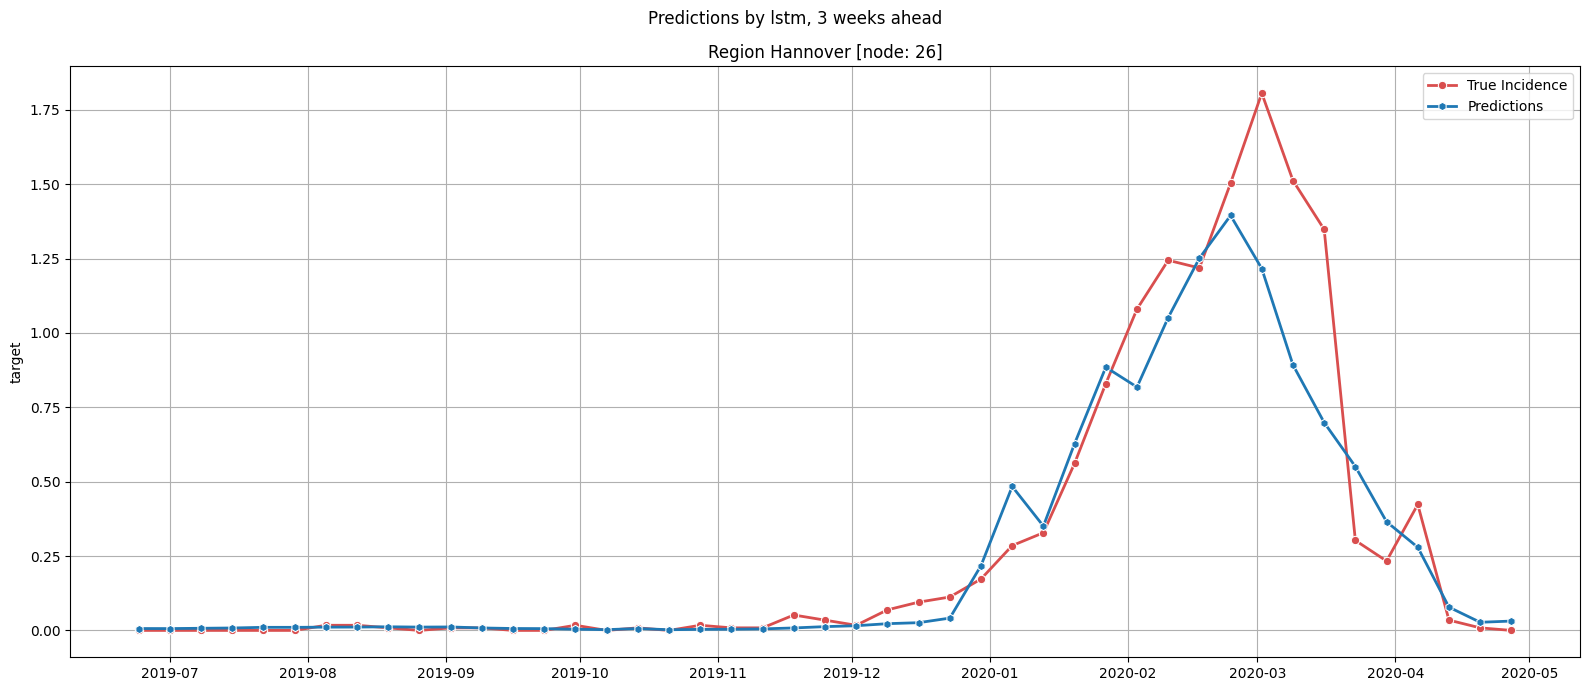

In [5]:
lstm = NodeLSTMModel(graphdataloader_id, name = 'lstm')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 2)
lstm.forecast('test')
lstm.show_forecasts(26)

## GATv2s


==                identity_graph                ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7349, val loss: 1.3070 ✓ (new best)
Epoch 2 train loss: 0.7055, val loss: 1.1107 ✓ (new best)
Epoch 3 train loss: 0.6883, val loss: 1.0223 ✓ (new best)


Epoch 4 train loss: 0.6735, val loss: 0.9685 ✓ (new best)
Epoch 5 train loss: 0.6632, val loss: 0.8716 ✓ (new best)
Epoch 6 train loss: 0.6562, val loss: 0.8549 ✓ (new best)
Epoch 7 train loss: 0.6559, val loss: 0.7738 ✓ (new best)
Epoch 8 train loss: 0.6457, val loss: 0.8023 (patience: 1/20)
Epoch 9 train loss: 0.6442, val loss: 0.7558 ✓ (new best)
Epoch 10 train loss: 0.6409, val loss: 0.7754 (patience: 1/20)
Epoch 11 train loss: 0.6311, val loss: 0.7572 (patience: 2/20)
Epoch 12 train loss: 0.6267, val loss: 0.7462 ✓ (new best)
Epoch 13 train loss: 0.6176, val loss: 0.7118 ✓ (new best)
Epoch 14 train loss: 0.6093, val loss: 0.7184 (patience: 1/20)
Epoch 15 train loss: 0.6052, val loss: 0.7078 ✓ (new best)
Epoch 16 train loss: 0.5975, val loss: 0.6819 ✓ (new best)
Epoch 17 train loss: 0.5867, val loss: 0.6921 (patience: 1/20)
Epoch 18 train loss: 0.5828, val loss: 0.6568 ✓ (new best)
Epoch 19 train loss: 0.5725, val loss: 0.6563 ✓ (new best)
Epoch 20 train loss: 0.5641, val loss: 0.6

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 562.45it/s]

Test loss: 0.9101



==              boolean neighbors               ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.7646, val loss: 1.3219 ✓ (new best)
Epoch 2 train loss: 0.7119, val loss: 1.0828 ✓ (new best)
Epoch 3 train loss: 0.6858, val loss: 1.0256 ✓ (new best)
Epoch 4 train loss: 0.6719, val loss: 0.8660 ✓ (new best)
Epoch 5 train loss: 0.6501, val loss: 0.8601 ✓ (new best)
Epoch 6 train loss: 0.6478, val loss: 0.8121 ✓ (new best)
Epoch 7 train loss: 0.6415, val loss: 0.7934 ✓ (new best)
Epoch 8 train loss: 0.6320, val loss: 0.7617 ✓ (new best)
Epoch 9 train loss: 0.6301, val loss: 0.7711 (patience: 1/20)
Epoch 10 train loss: 0.6250, val loss: 0.7217 ✓ (new best)
Epoch 11 train loss: 0.6150, val loss: 0.7235 (patience: 1/20)
Epoch 12 train loss: 0.6066, val loss: 0.6831 ✓ (new best)
Epoch 13 train loss: 0.6010, val loss: 0.6671 ✓ (new best)
Epoch 14 train loss: 0.5927, val loss: 0.6398 ✓ (new best)
Epoch 15 train loss: 0

...

Test loss: 0.8080



==                  commuter 3                  ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2285), edge_weight=(2285,))
Epoch 1 train loss: 0.7522, val loss: 1.2768 ✓ (new best)
Epoch 2 train loss: 0.7103, val loss: 1.1201 ✓ (new best)
Epoch 3 train loss: 0.6781, val loss: 0.9556 ✓ (new best)
Epoch 4 train loss: 0.6695, val loss: 0.9145 ✓ (new best)
Epoch 5 train loss: 0.6609, val loss: 0.8573 ✓ (new best)
Epoch 6 train loss: 0.6495, val loss: 0.8286 ✓ (new best)
Epoch 7 train loss: 0.6459, val loss: 0.8040 ✓ (new best)
Epoch 8 train loss: 0.6396, val loss: 0.7894 ✓ (new best)
Epoch 9 train loss: 0.6339, val loss: 0.7696 ✓ (new best)
Epoch 10 train loss: 0.6318, val loss: 0.7569 ✓ (new best)
Epoch 11 train loss: 0.6247, val loss: 0.7300 ✓ (new best)
Epoch 12 train loss: 0.6144, val loss: 0.7144 ✓ (new best)
Epoch 13 train loss: 0.6033, val loss: 0.6859 ✓ (new best)
Epoch 14 train loss: 0.5955, val loss: 0.6780 ✓ (new best)
Epoch 15 train loss: 0.5823, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 561.54it/s]

Test loss: 0.8279


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

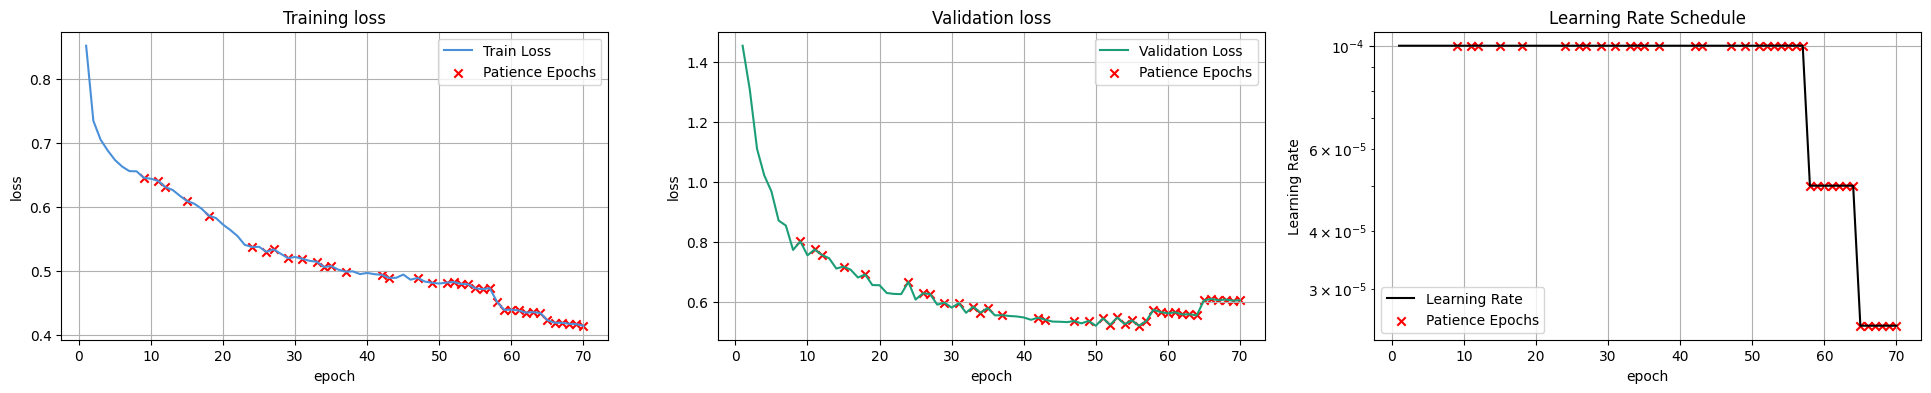

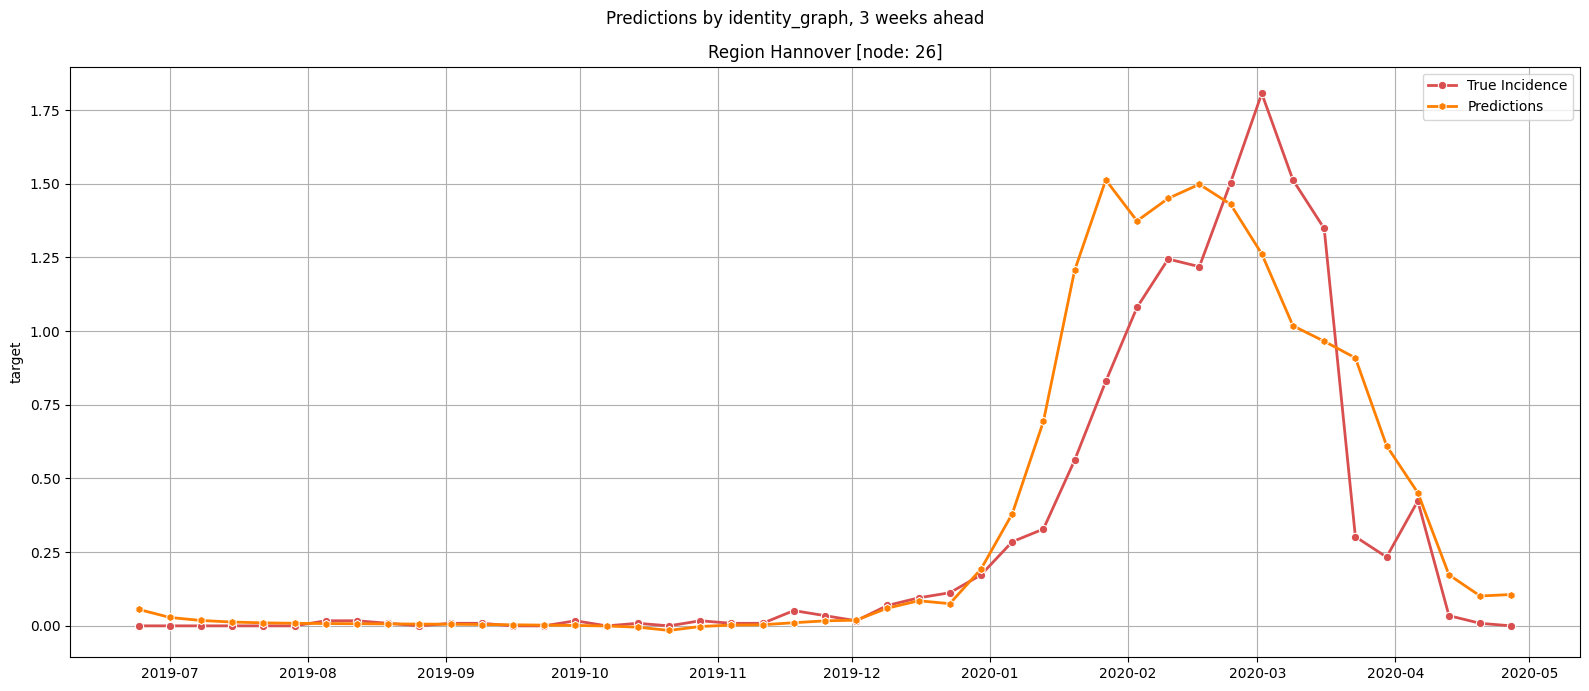

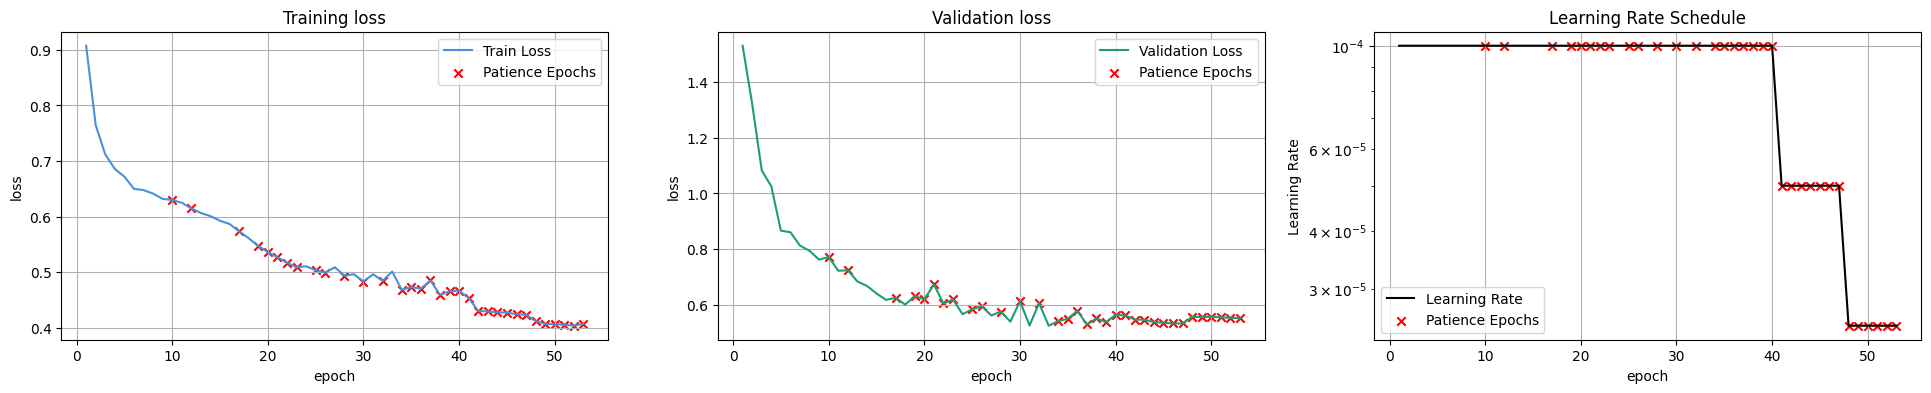

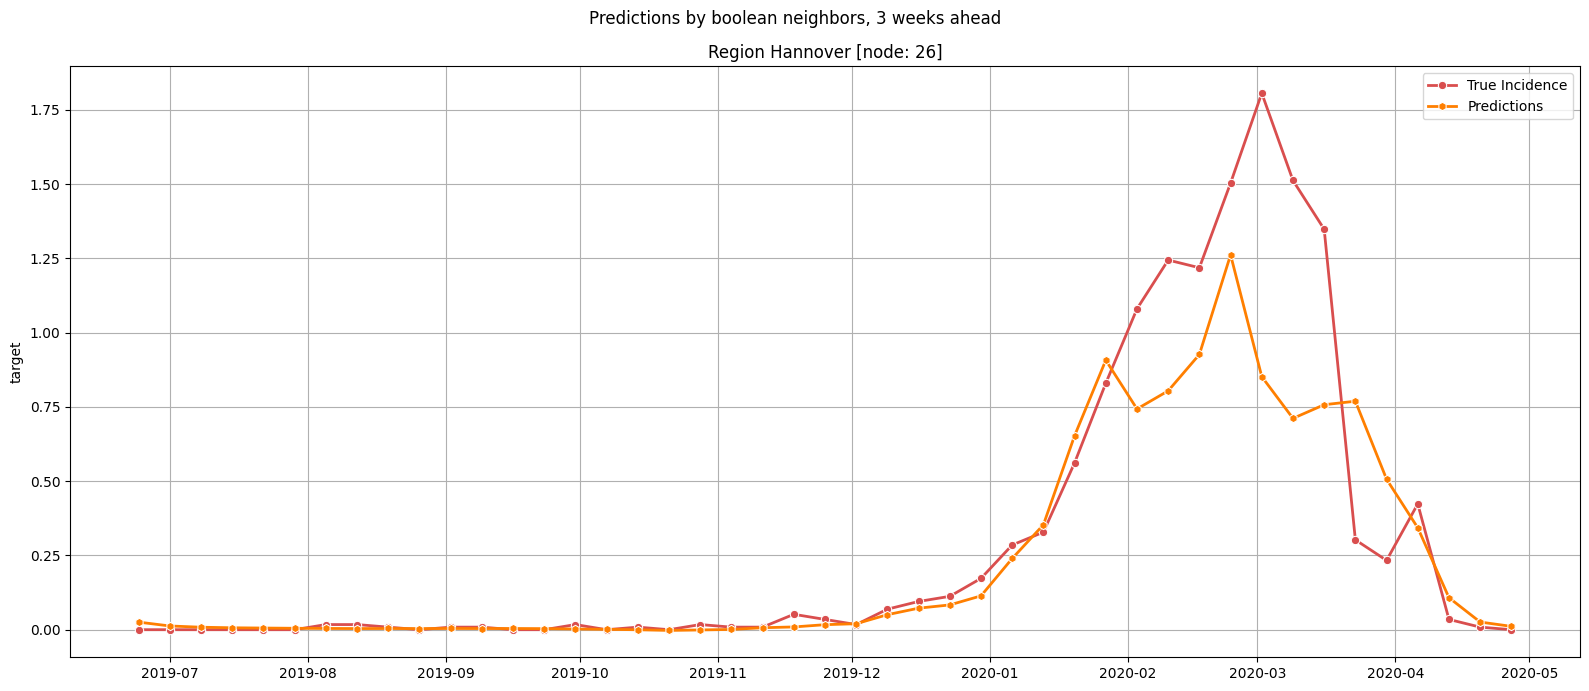

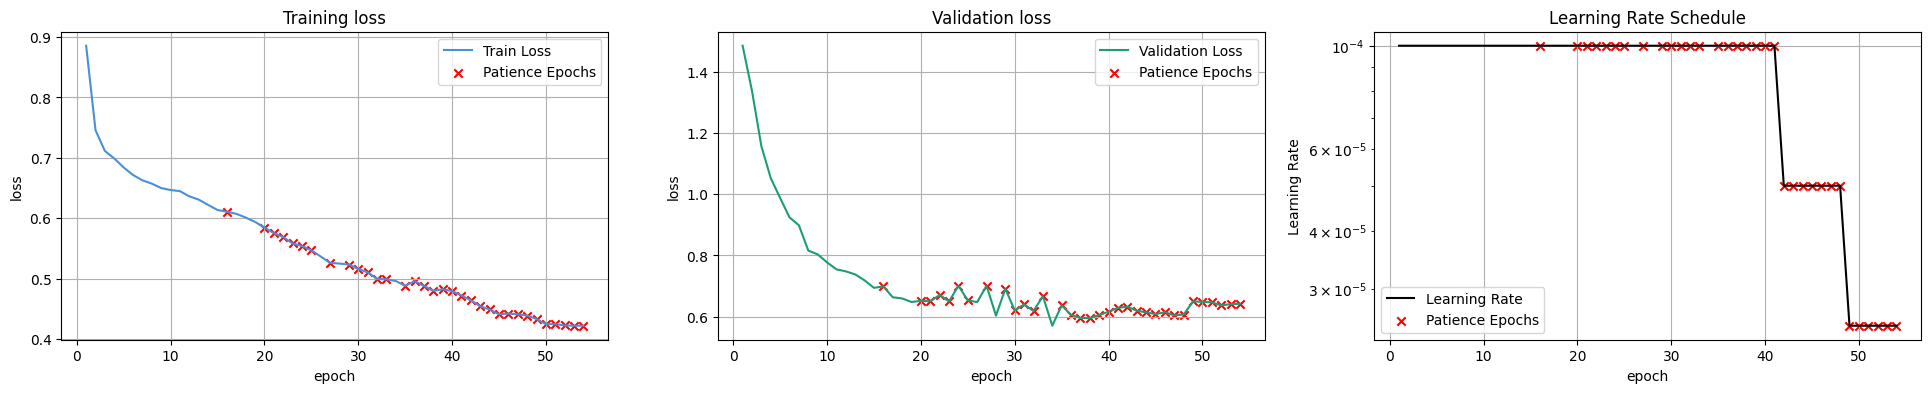

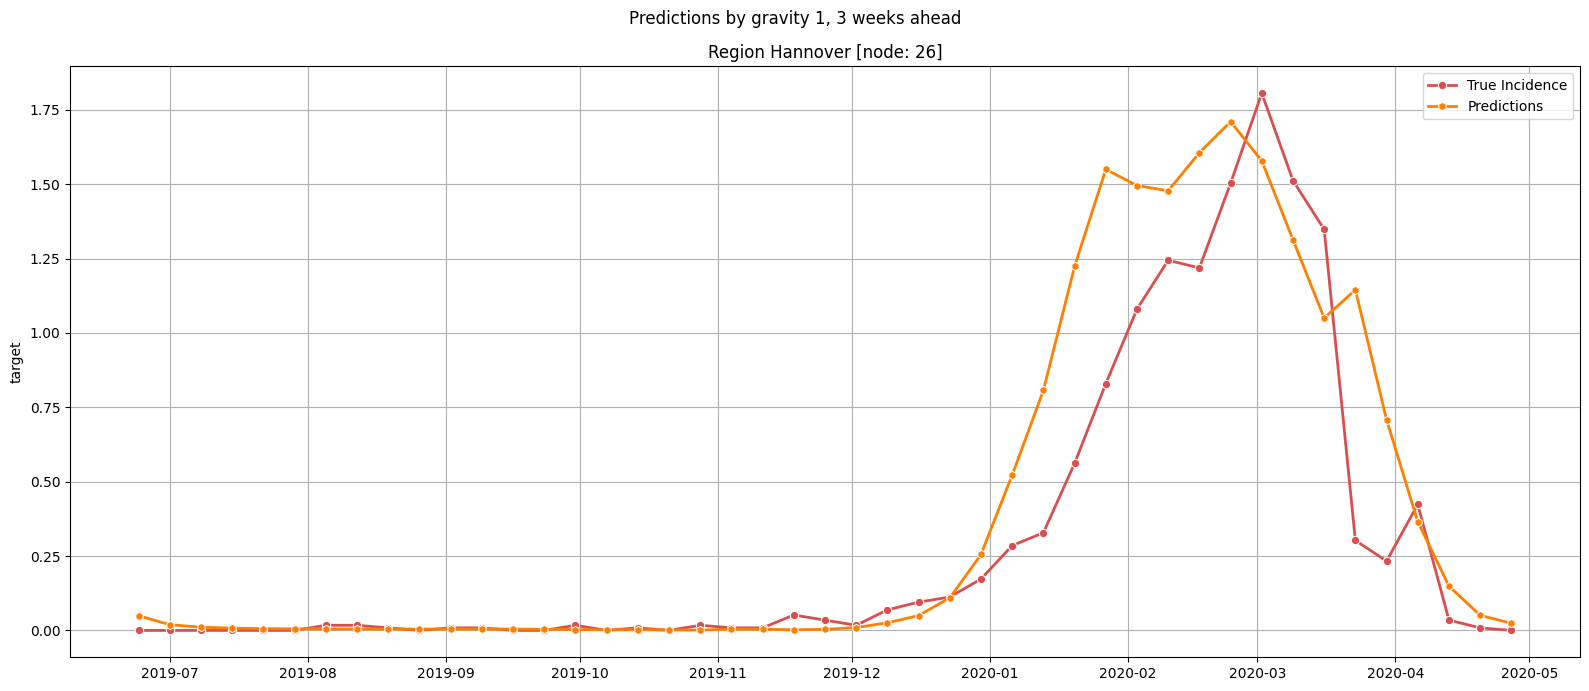

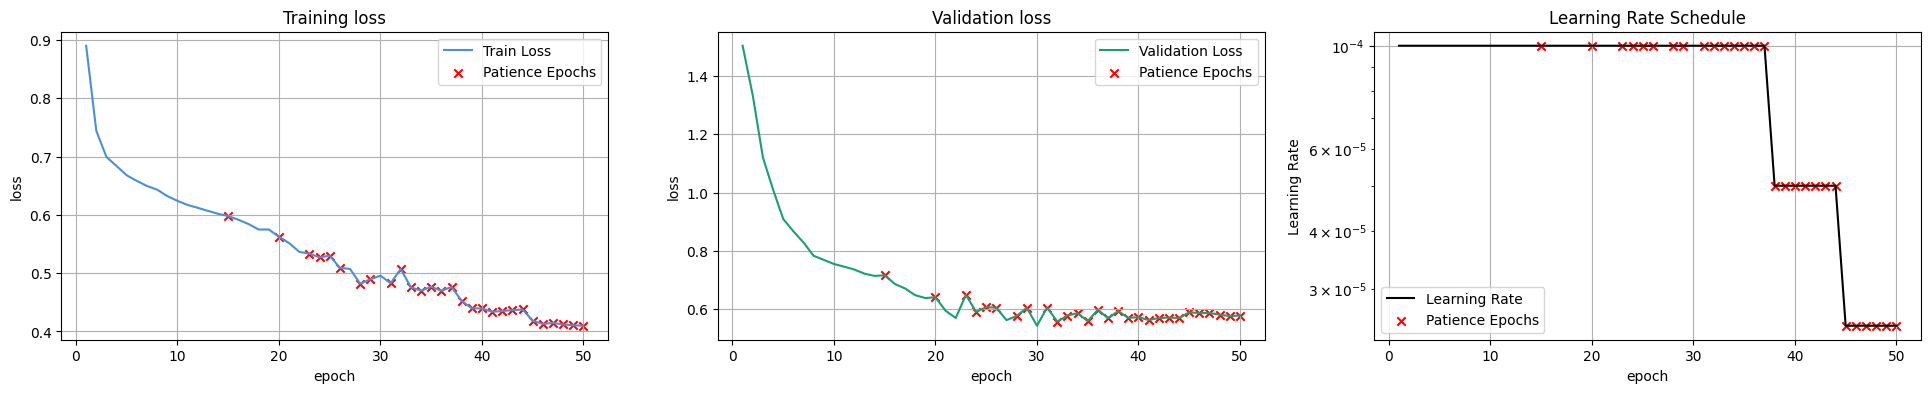

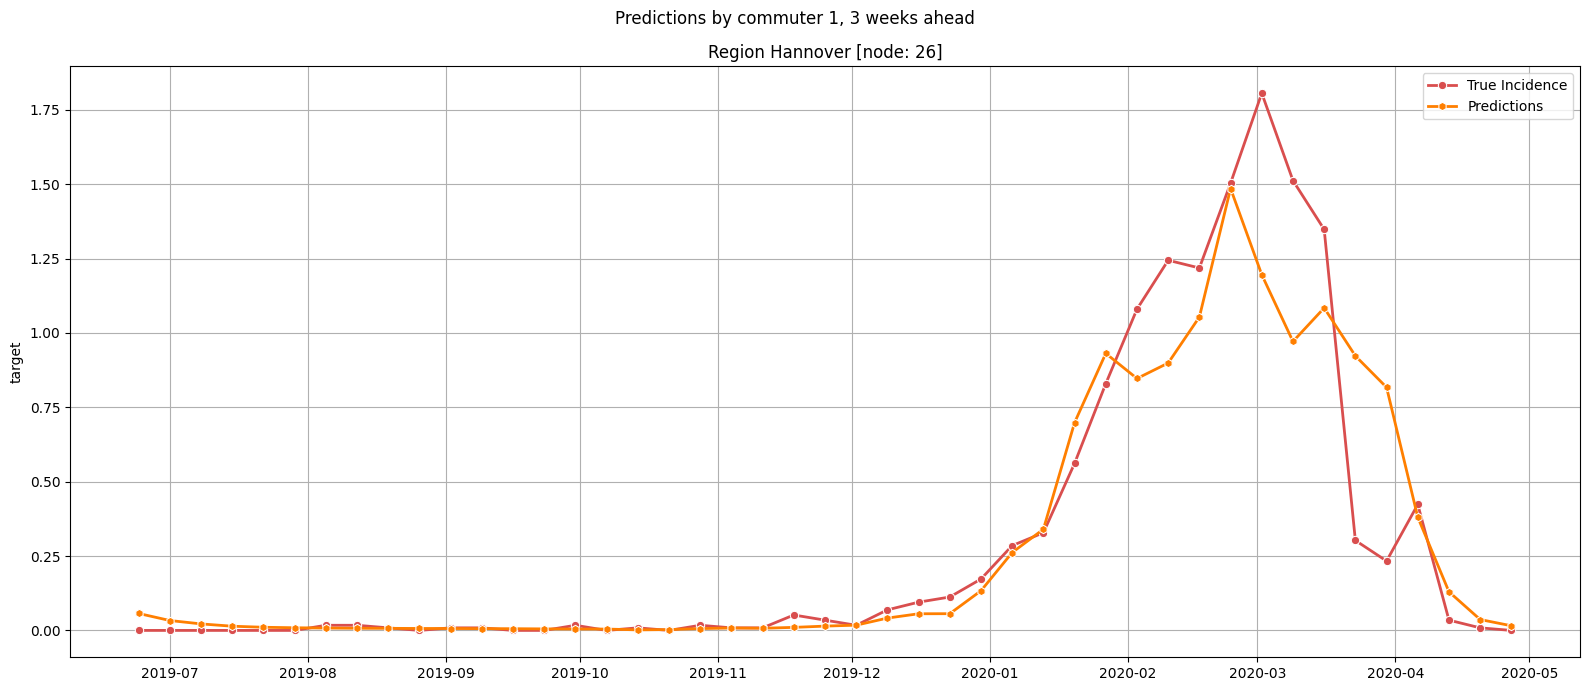

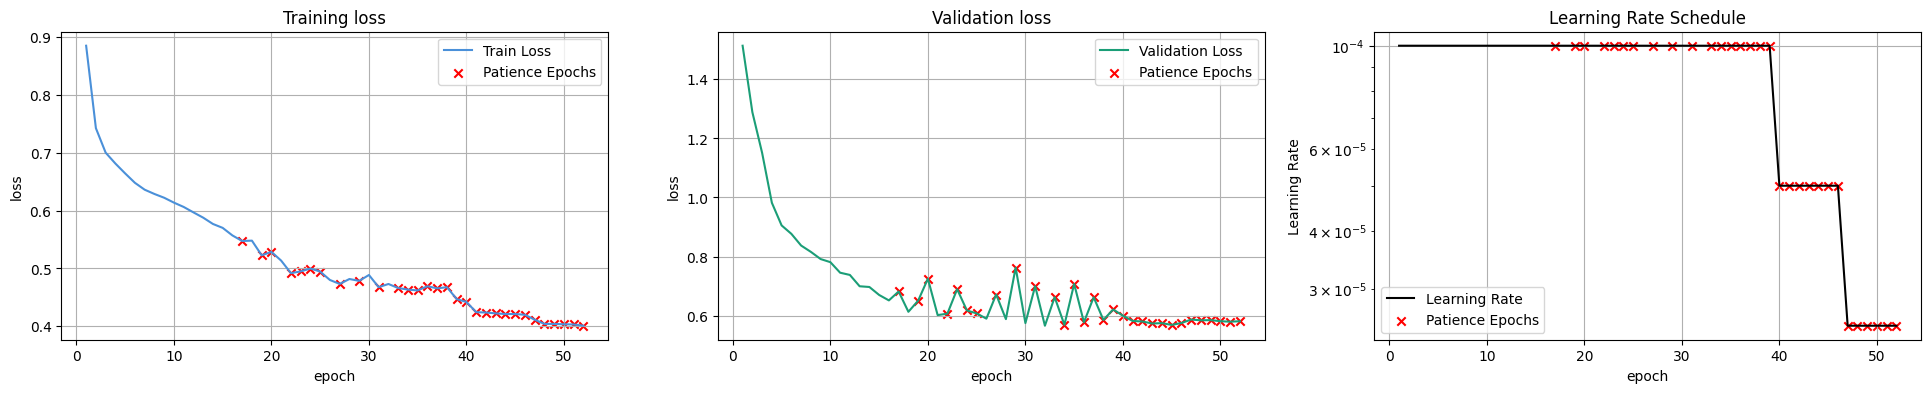

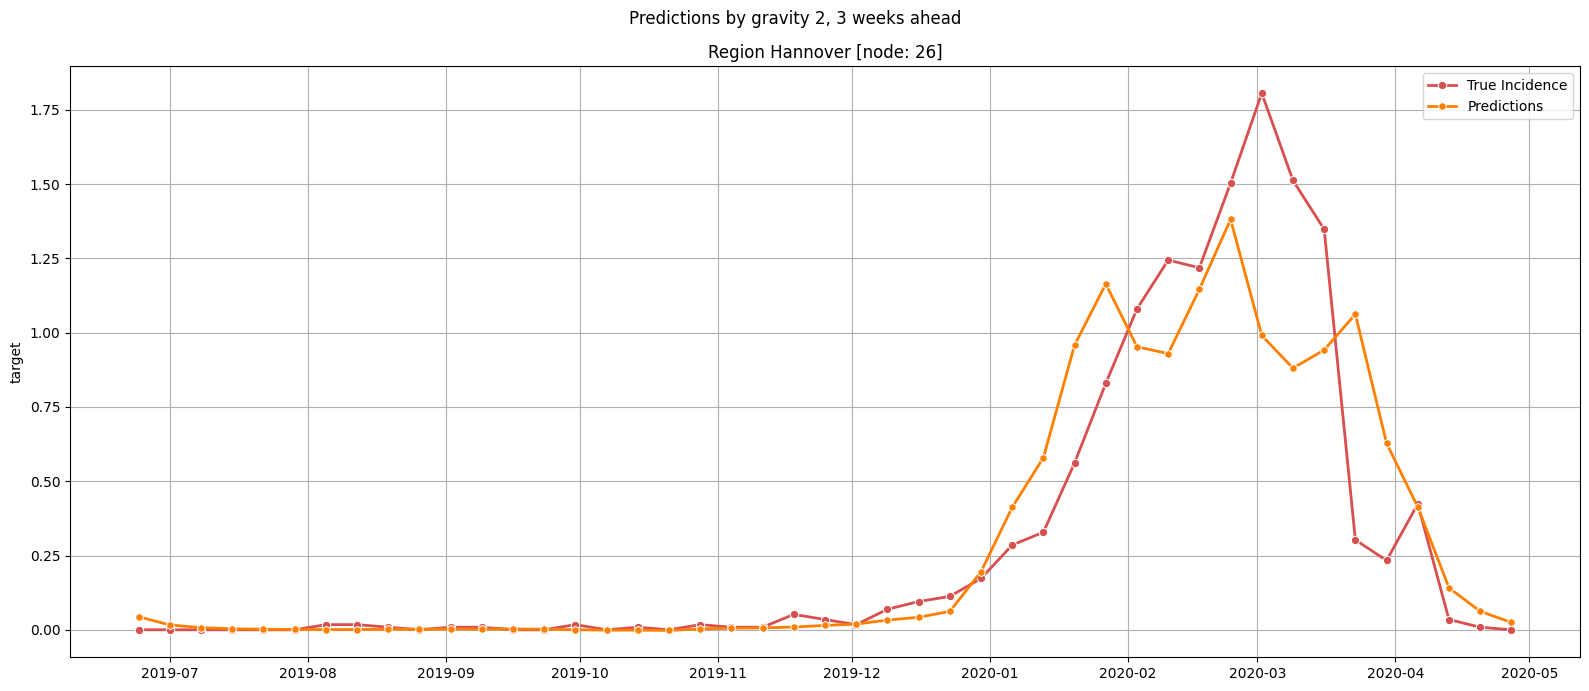

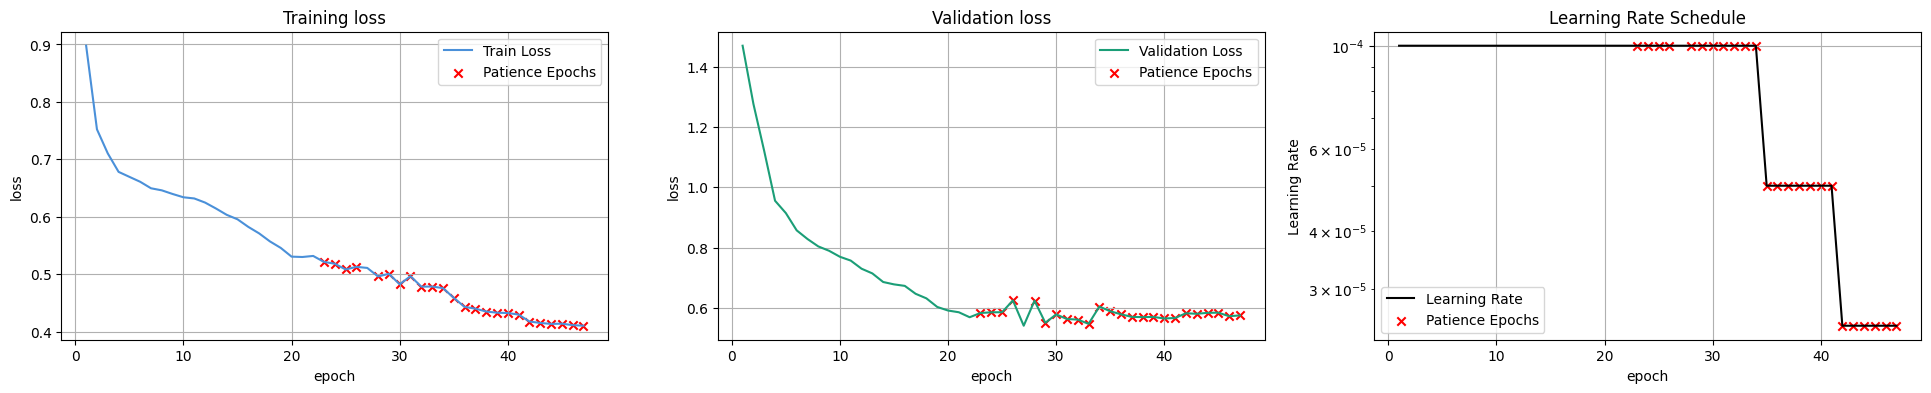

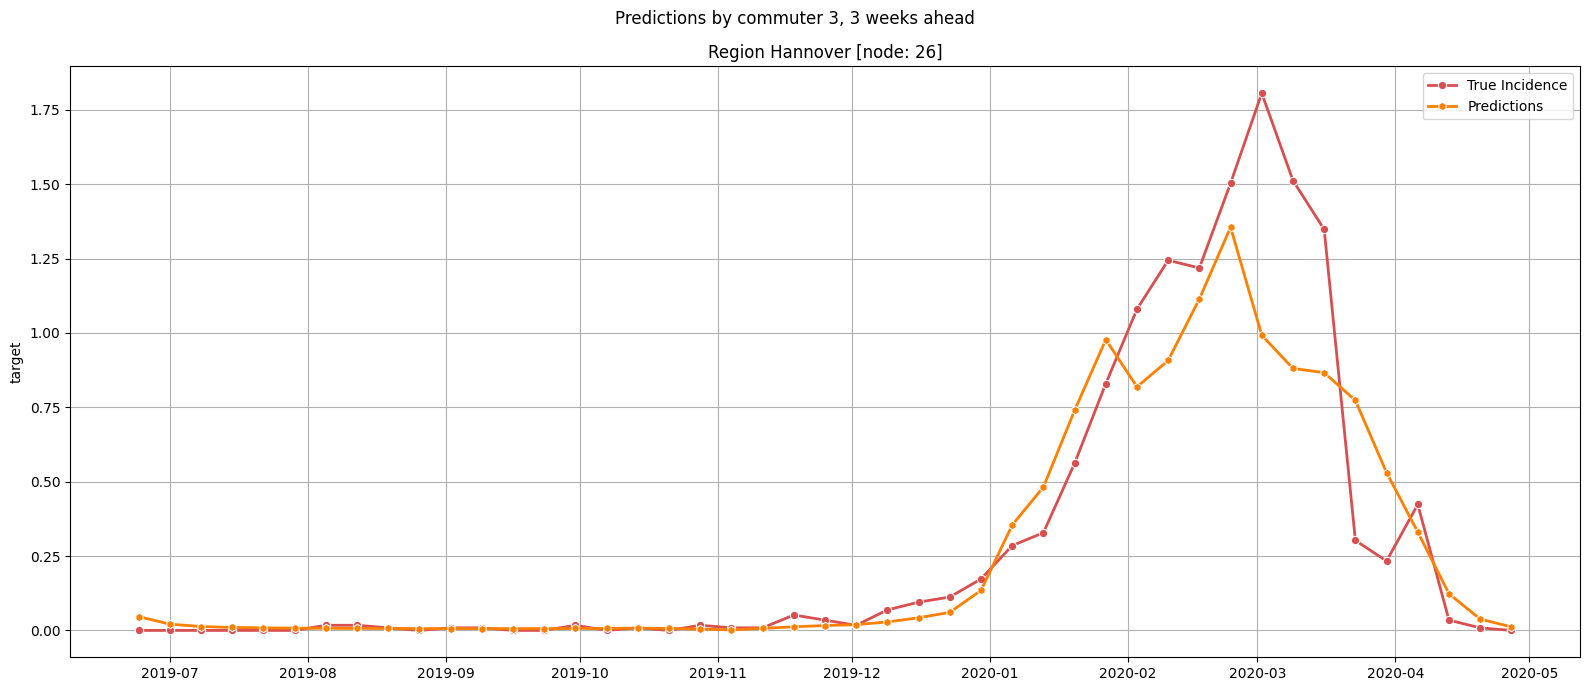

In [6]:
spatiotemporal_model1 = GATv2Model(graphdataloader_id, name = 'identity_graph')
spatiotemporal_model1.set_model_hparams()
spatiotemporal_model1.set_global_hparams(**global_hparams)
spatiotemporal_model1.train(verbose = 2)
spatiotemporal_model1.forecast('test')
spatiotemporal_model1.show_forecasts(26)

spatiotemporal_model2 = GATv2Model(graphdataloader_bn, name = 'boolean neighbors')
spatiotemporal_model2.set_model_hparams()
spatiotemporal_model2.set_global_hparams(**global_hparams)
spatiotemporal_model2.train(verbose = 2)
spatiotemporal_model2.forecast('test')
spatiotemporal_model2.show_forecasts(26)

spatiotemporal_model3 = GATv2Model(graphdataloader_gr1, name = 'gravity 1')
spatiotemporal_model3.set_model_hparams()
spatiotemporal_model3.set_global_hparams(**global_hparams)
spatiotemporal_model3.train(verbose = 2)
spatiotemporal_model3.forecast('test')
spatiotemporal_model3.show_forecasts(26)

spatiotemporal_model4 = GATv2Model(graphdataloader_cm1, name = 'commuter 1')
spatiotemporal_model4.set_model_hparams()
spatiotemporal_model4.set_global_hparams(**global_hparams)
spatiotemporal_model4.train(verbose = 2)
spatiotemporal_model4.forecast('test')
spatiotemporal_model4.show_forecasts(26)

spatiotemporal_model5 = GATv2Model(graphdataloader_gr2, name = 'gravity 2')
spatiotemporal_model5.set_model_hparams()
spatiotemporal_model5.set_global_hparams(**global_hparams)
spatiotemporal_model5.train(verbose = 2)
spatiotemporal_model5.forecast('test')
spatiotemporal_model5.show_forecasts(26)

spatiotemporal_model6 = GATv2Model(graphdataloader_cm2, name = 'commuter 3')
spatiotemporal_model6.set_model_hparams()
spatiotemporal_model6.set_global_hparams(**global_hparams)
spatiotemporal_model6.train(verbose = 2)
spatiotemporal_model6.forecast('test')
spatiotemporal_model6.show_forecasts(26)

## GCNs


==                identity_graph                ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7677, val loss: 1.5621 ✓ (new best)
Epoch 2 train loss: 0.6736, val loss: 1.2988 ✓ (new best)
Epoch 3 train loss: 0.6468, val loss: 1.1898 ✓ (new best)
Epoch 4 train loss: 0.6328, val loss: 1.1223 ✓ (new best)
Epoch 5 train loss: 0.6209, val loss: 1.0716 ✓ (new best)
Epoch 6 train loss: 0.6134, val loss: 1.0303 ✓ (new best)
Epoch 7 train loss: 0.6073, val loss: 0.9963 ✓ (new best)
Epoch 8 train loss: 0.6015, val loss: 0.9669 ✓ (new best)
Epoch 9 train loss: 0.5979, val loss: 0.9422 ✓ (new best)
Epoch 10 train loss: 0.5951, val loss: 0.9219 ✓ (new best)
Epoch 11 train loss: 0.5908, val loss: 0.9031 ✓ (new best)
Epoch 12 train loss: 0.5905, val loss: 0.8893 ✓ (new best)
Epoch 13 train loss: 0.5859, val loss: 0.8703 ✓ (new best)
Epoch 14 train loss: 0.5859, val loss: 0.8595 ✓ (new best)
Epoch 15 train loss: 0.5820, val

Epoch 17 train loss: 0.5824, val loss: 0.8327 ✓ (new best)
Epoch 18 train loss: 0.5781, val loss: 0.8246 ✓ (new best)
Epoch 19 train loss: 0.5763, val loss: 0.8141 ✓ (new best)
Epoch 20 train loss: 0.5717, val loss: 0.8077 ✓ (new best)
Epoch 21 train loss: 0.5735, val loss: 0.8039 ✓ (new best)
Epoch 22 train loss: 0.5731, val loss: 0.7988 ✓ (new best)
Epoch 23 train loss: 0.5693, val loss: 0.7886 ✓ (new best)
Epoch 24 train loss: 0.5684, val loss: 0.7872 ✓ (new best)
Epoch 25 train loss: 0.5693, val loss: 0.7804 ✓ (new best)
Epoch 26 train loss: 0.5655, val loss: 0.7739 ✓ (new best)
Epoch 27 train loss: 0.5679, val loss: 0.7731 ✓ (new best)
Epoch 28 train loss: 0.5668, val loss: 0.7683 ✓ (new best)
Epoch 29 train loss: 0.5623, val loss: 0.7602 ✓ (new best)
Epoch 30 train loss: 0.5624, val loss: 0.7597 ✓ (new best)
Epoch 31 train loss: 0.5635, val loss: 0.7579 ✓ (new best)
Epoch 32 train loss: 0.5602, val loss: 0.7503 ✓ (new best)
Epoch 33 train loss: 0.5588, val loss: 0.7459 ✓ (new bes

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 626.71it/s]


Test loss: 1.0371

==              boolean neighbors               ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.7348, val loss: 1.4284 ✓ (new best)
Epoch 2 train loss: 0.6604, val loss: 1.2135 ✓ (new best)
Epoch 3 train loss: 0.6381, val loss: 1.1250 ✓ (new best)
Epoch 4 train loss: 0.6277, val loss: 1.0692 ✓ (new best)
Epoch 5 train loss: 0.6152, val loss: 1.0247 ✓ (new best)
Epoch 6 train loss: 0.6110, val loss: 0.9903 ✓ (new best)
Epoch 7 train loss: 0.6056, val loss: 0.9611 ✓ (new best)
Epoch 8 train loss: 0.6006, val loss: 0.9393 ✓ (new best)
Epoch 9 train loss: 0.5945, val loss: 0.9179 ✓ (new best)
Epoch 10 train loss: 0.5929, val loss: 0.9016 ✓ (new best)
Epoch 11 train loss: 0.5896, val loss: 0.8858 ✓ (new best)
Epoch 12 train loss: 0.5864, val loss: 0.8747 ✓ (new best)
Epoch 13 train loss: 0.5824, val loss: 0.8627 ✓ (new best)
Epoch 14 train loss: 0.5808, val loss: 0.8534 ✓ (new best)
Epoch 15 tra

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 609.28it/s]

...

Test loss: 0.9404



==                  commuter 3                  ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2285), edge_weight=(2285,))
Epoch 1 train loss: 0.7123, val loss: 1.4155 ✓ (new best)
Epoch 2 train loss: 0.6663, val loss: 1.2643 ✓ (new best)
Epoch 3 train loss: 0.6476, val loss: 1.1839 ✓ (new best)
Epoch 4 train loss: 0.6378, val loss: 1.1308 ✓ (new best)
Epoch 5 train loss: 0.6260, val loss: 1.0881 ✓ (new best)
Epoch 6 train loss: 0.6209, val loss: 1.0530 ✓ (new best)
Epoch 7 train loss: 0.6170, val loss: 1.0262 ✓ (new best)
Epoch 8 train loss: 0.6145, val loss: 1.0046 ✓ (new best)
Epoch 9 train loss: 0.6084, val loss: 0.9823 ✓ (new best)
Epoch 10 train loss: 0.6069, val loss: 0.9672 ✓ (new best)
Epoch 11 train loss: 0.6026, val loss: 0.9498 ✓ (new best)
Epoch 12 train loss: 0.5974, val loss: 0.9337 ✓ (new best)
Epoch 13 train loss: 0.5979, val loss: 0.9206 ✓ (new best)
Epoch 14 train loss: 0.5934, val loss: 0.9092 ✓ (new best)
Epoch 15 train loss: 0.5912, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 553.45it/s]

Test loss: 0.9802


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

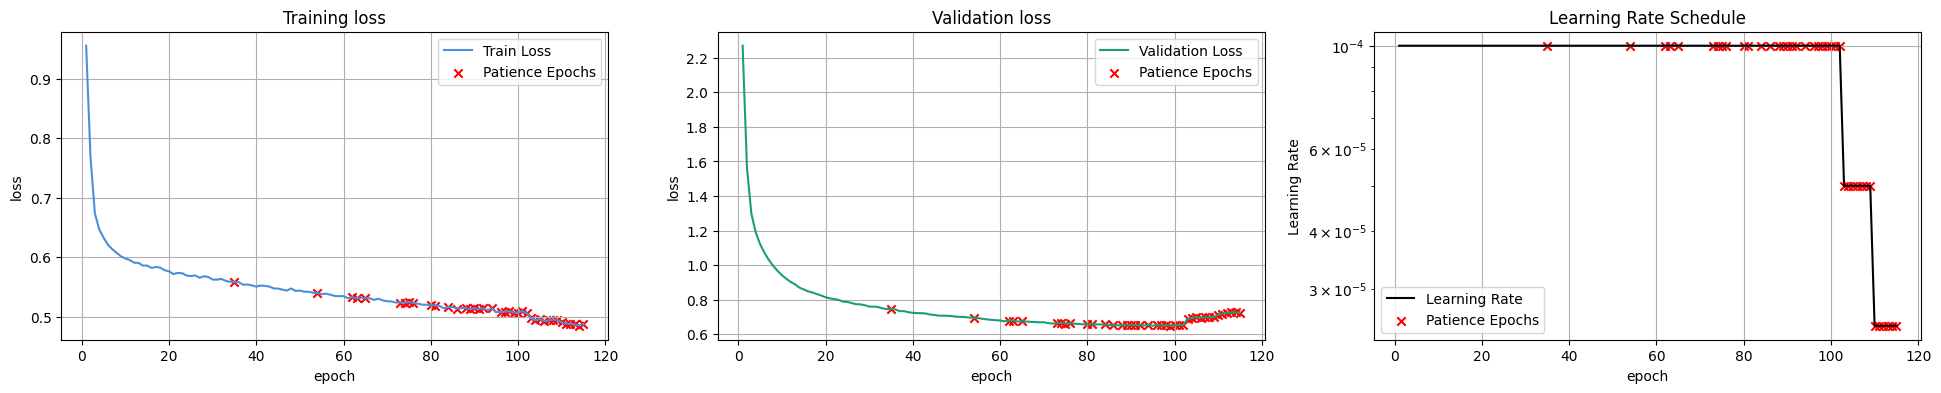

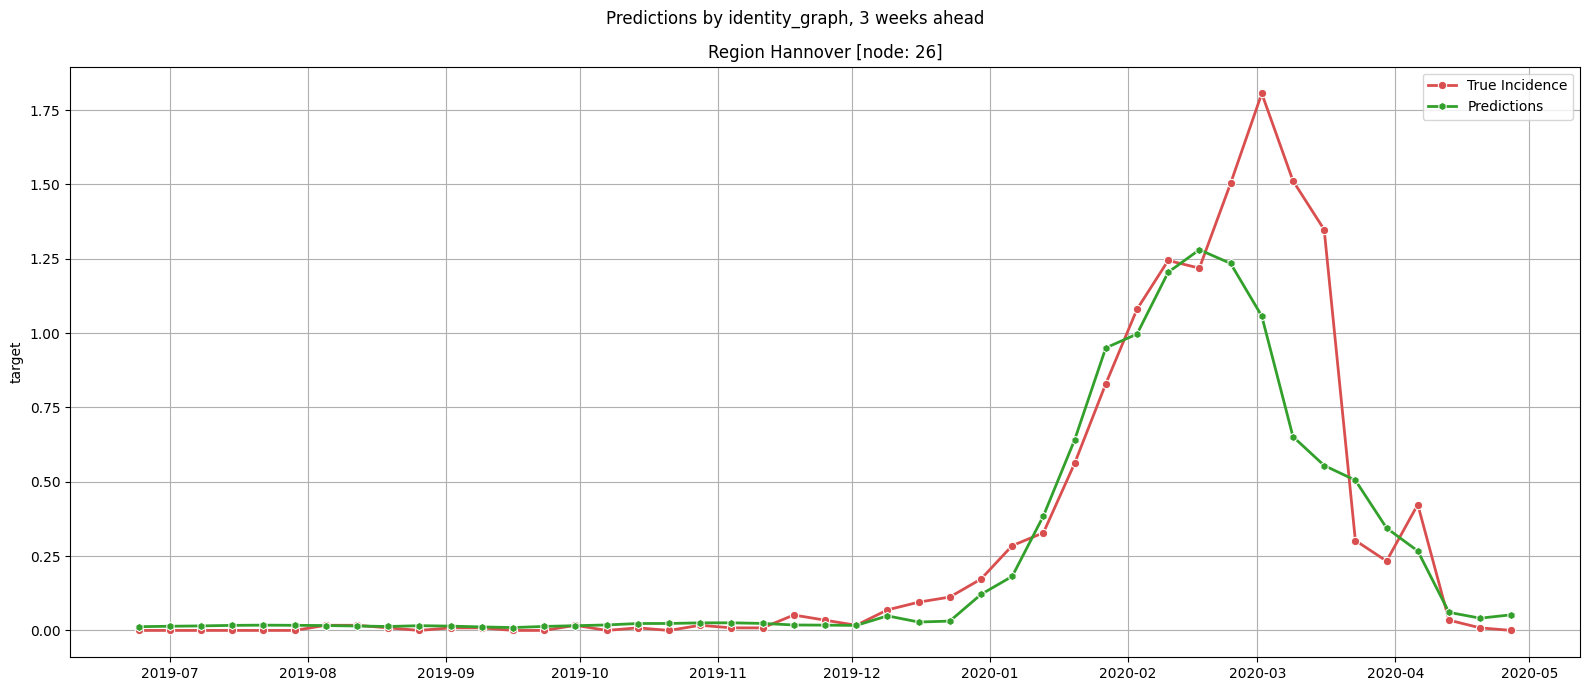

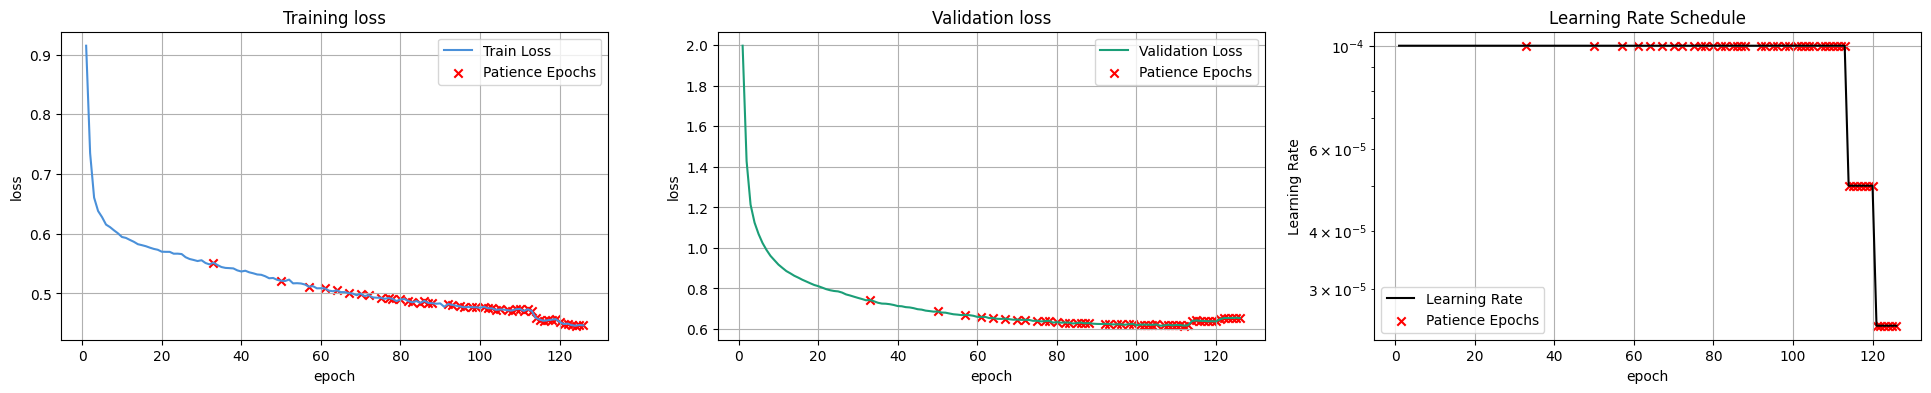

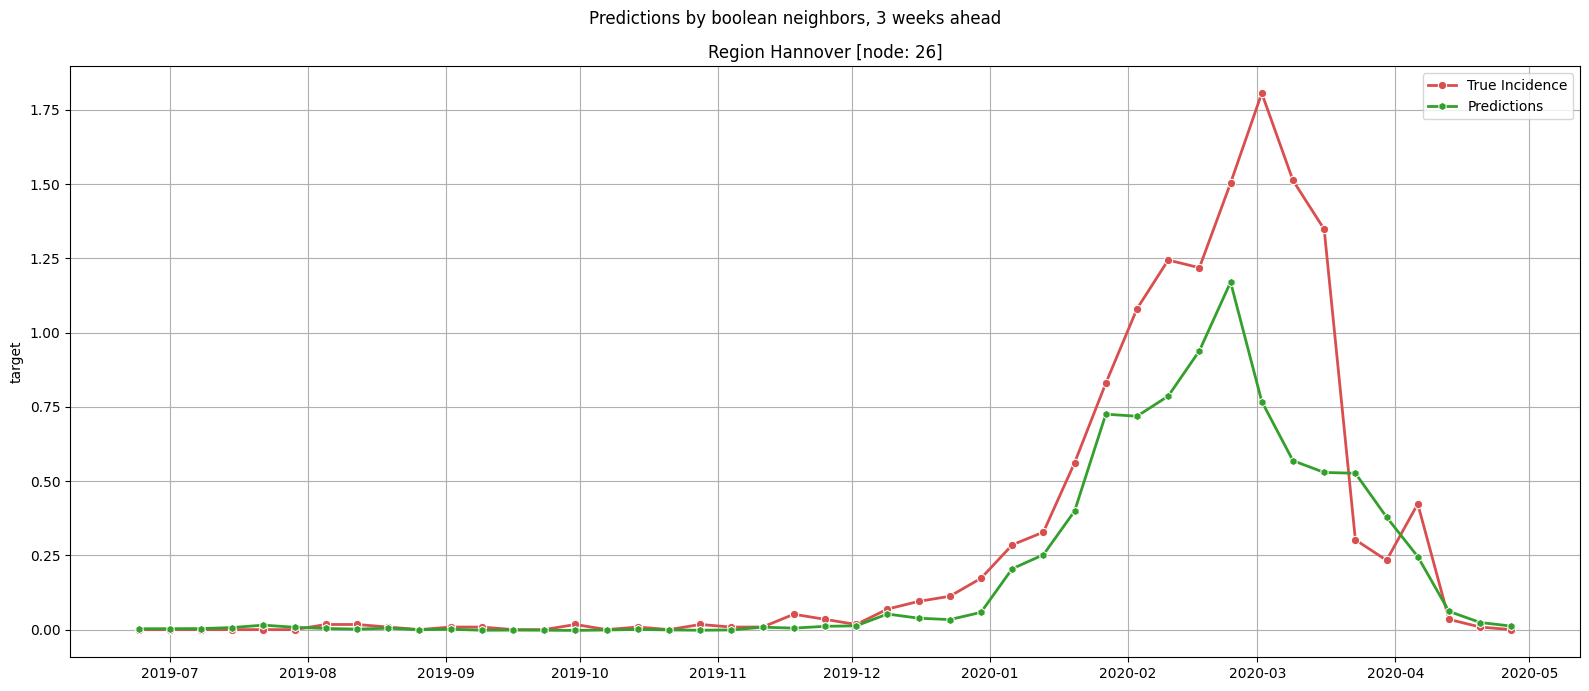

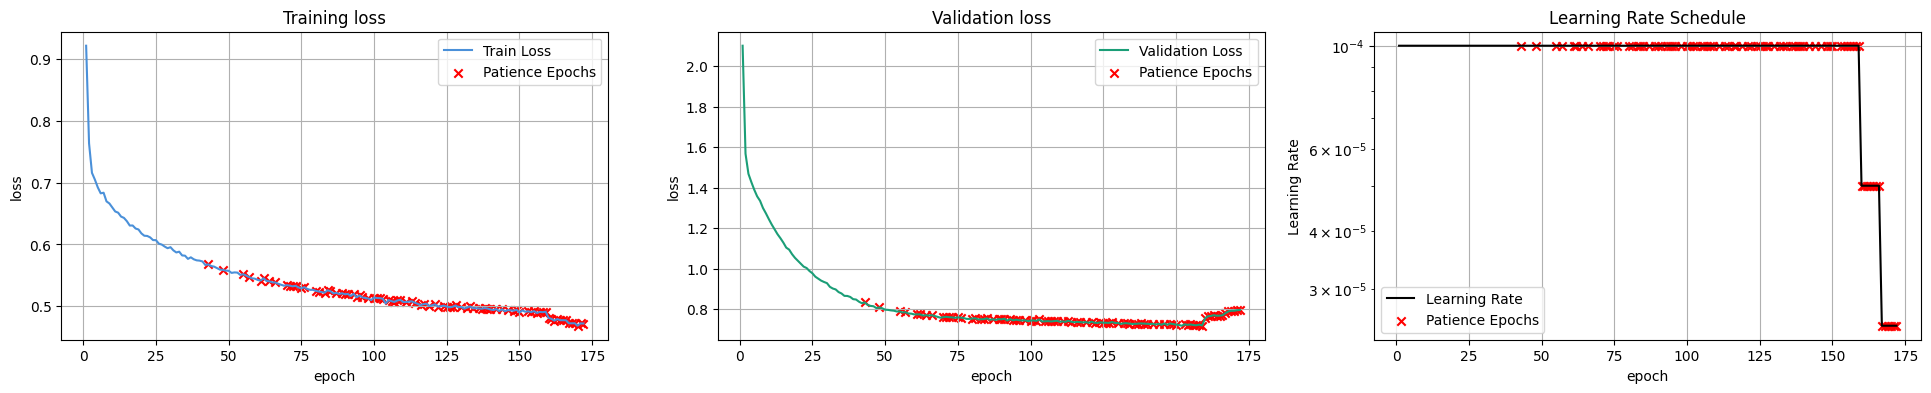

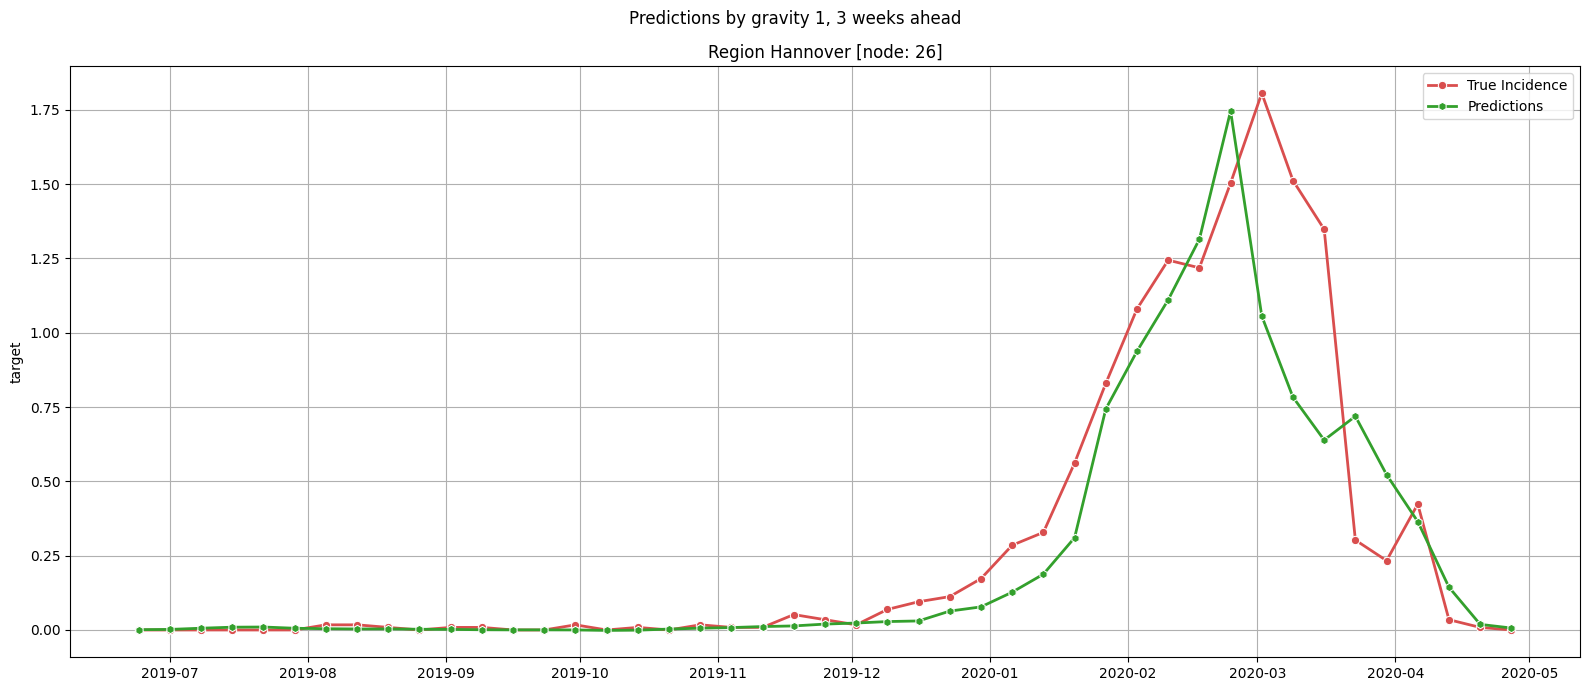

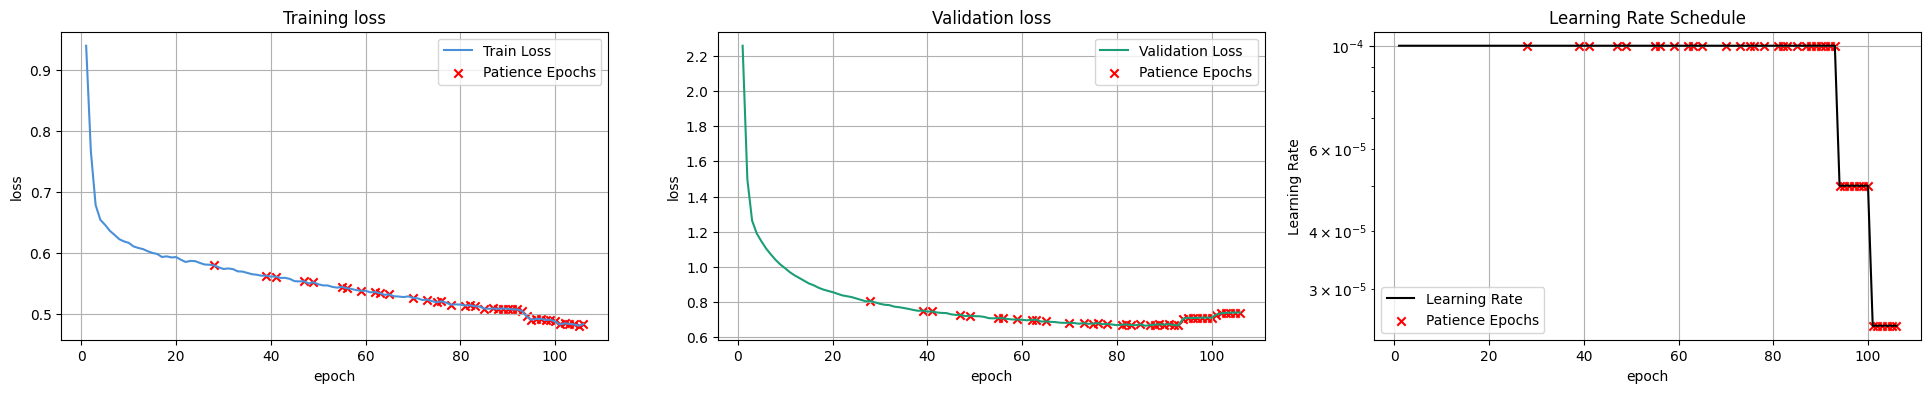

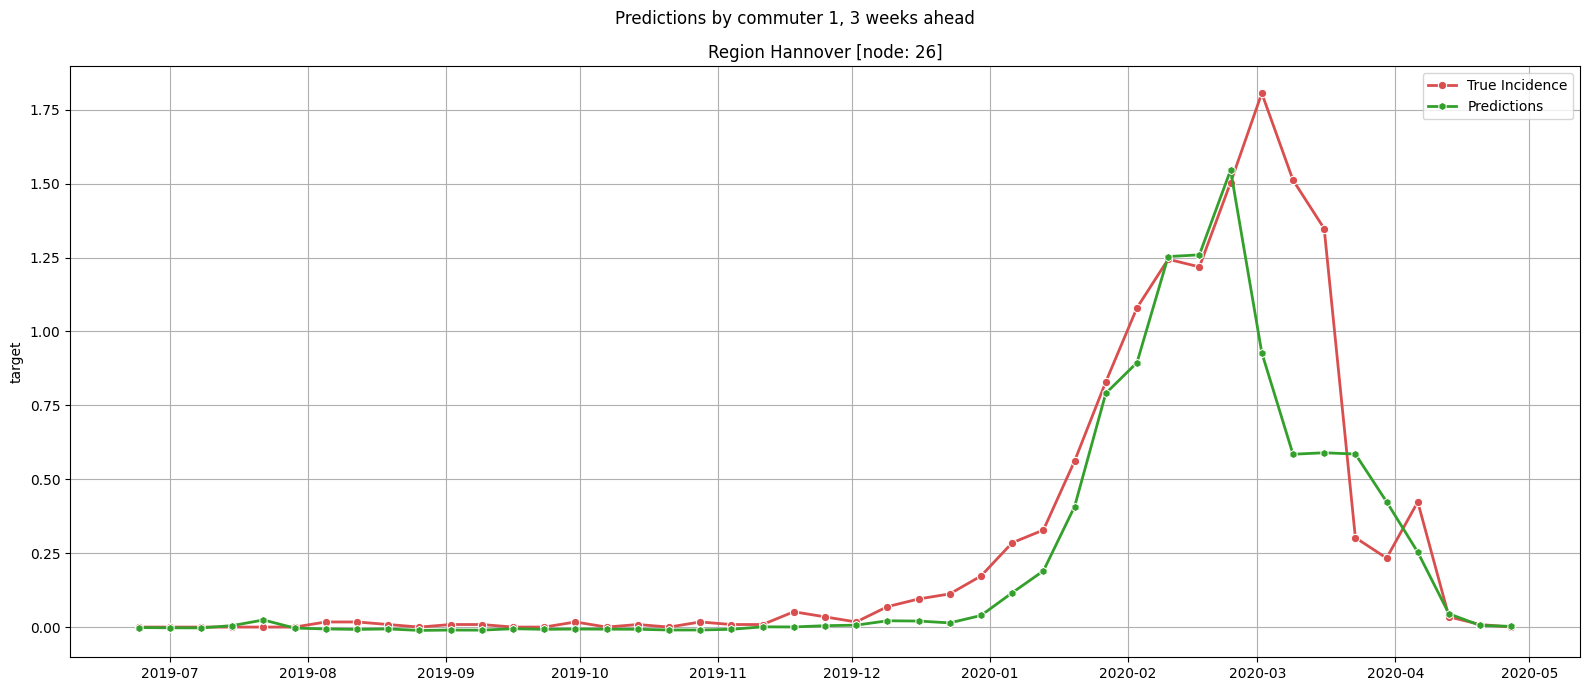

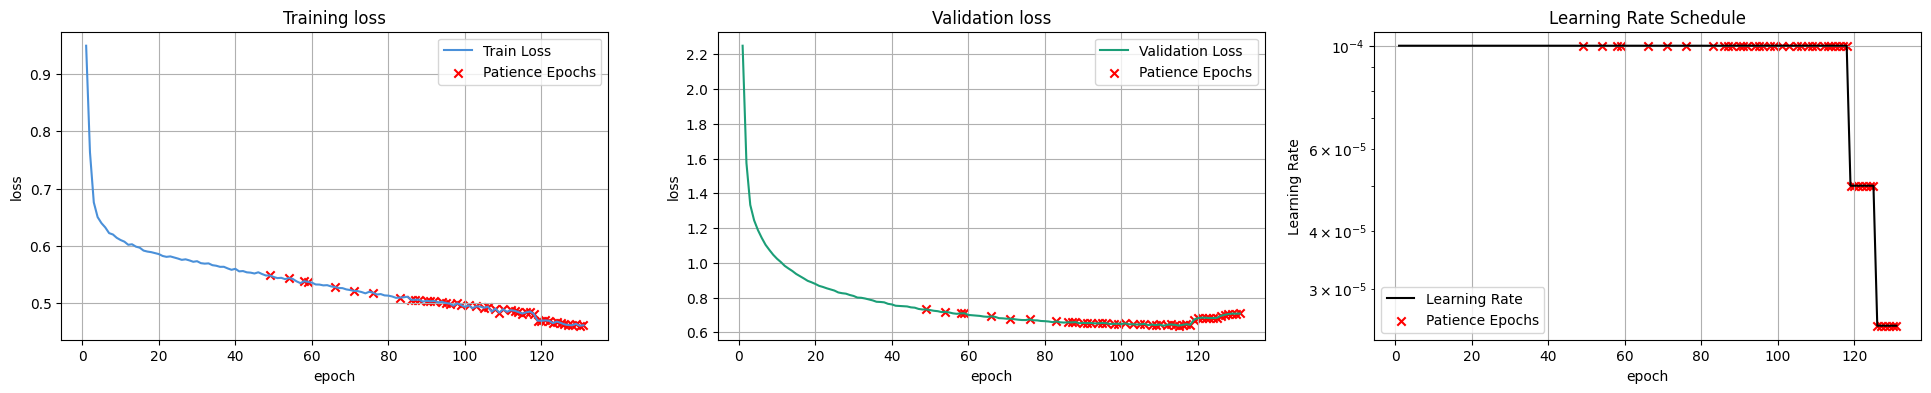

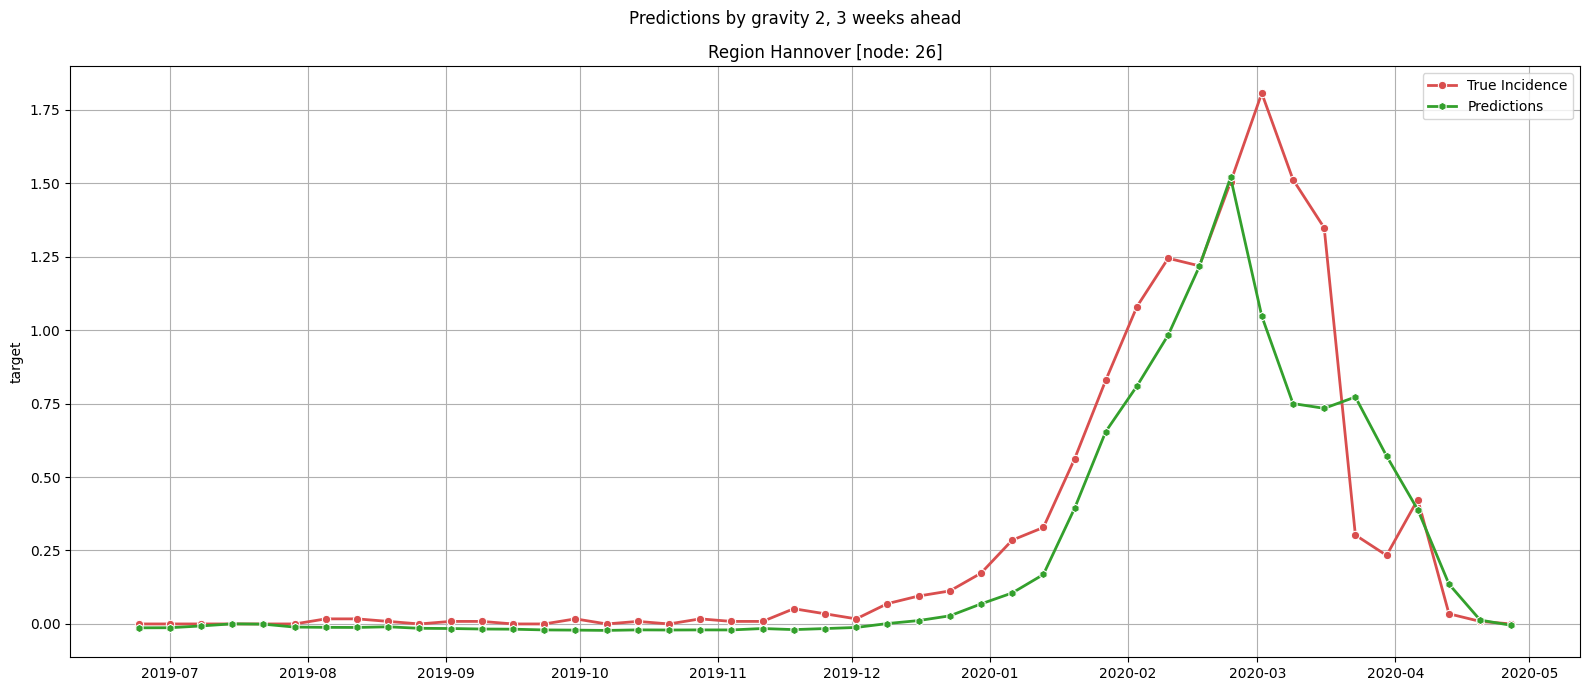

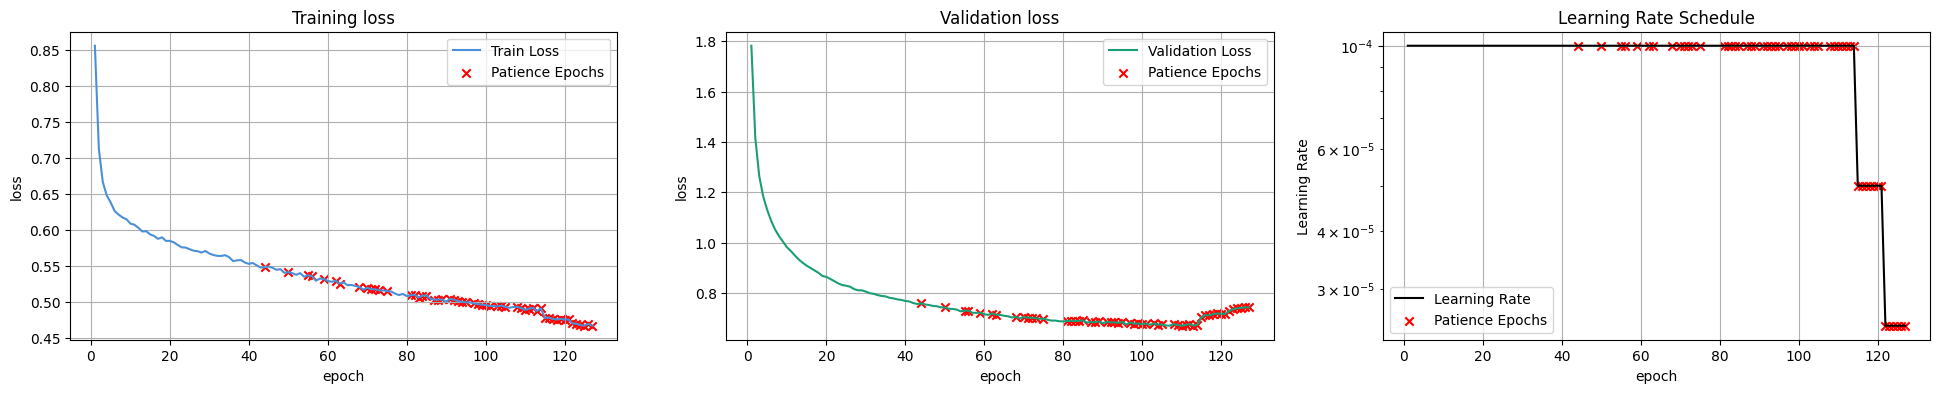

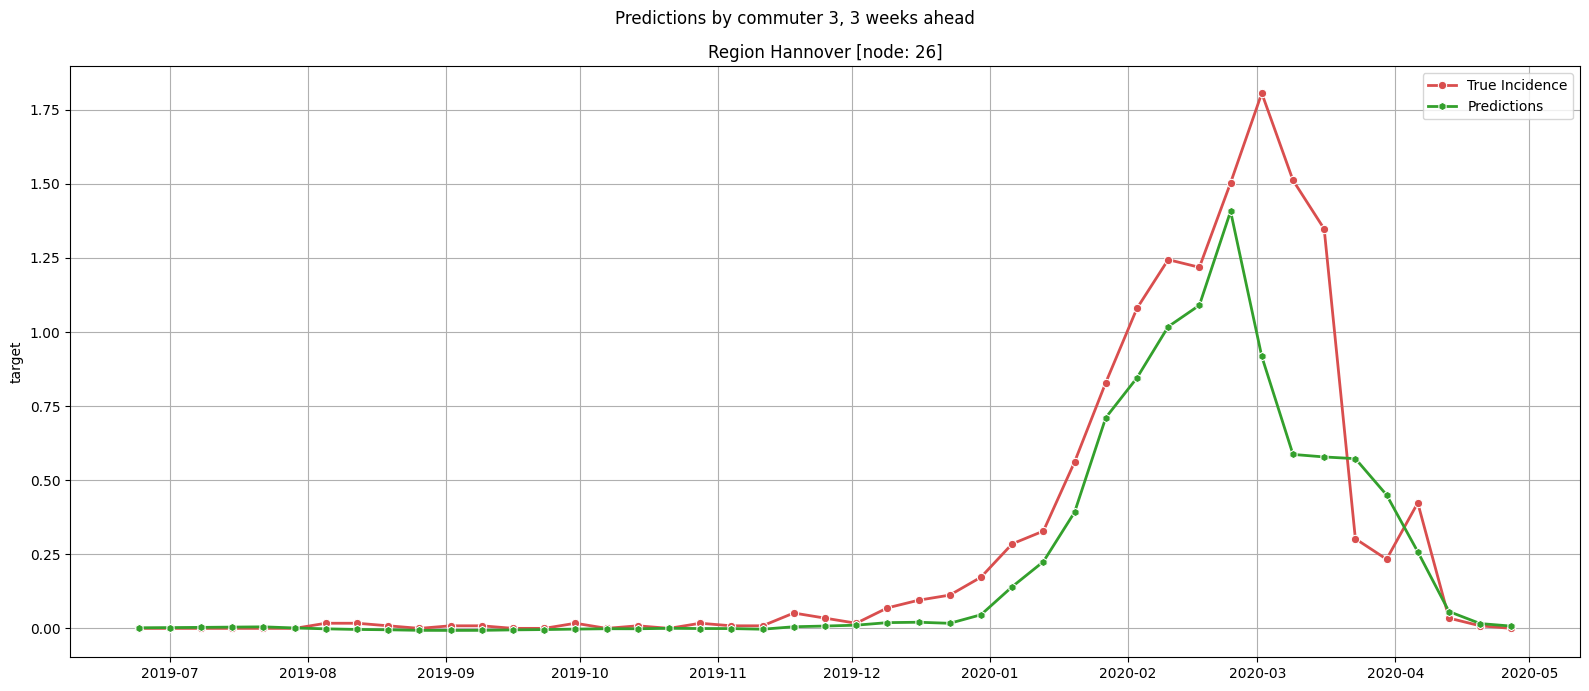

In [7]:
from srcv2.models.deep.spatialgnnmodel import SpatialGNNModel
spatial_model1 = SpatialGNNModel(graphdataloader_id, name = 'identity_graph')
spatial_model1.set_model_hparams()
spatial_model1.set_global_hparams(**global_hparams)
spatial_model1.train(verbose = 2)
spatial_model1.forecast('test')
spatial_model1.show_forecasts(26)

spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'boolean neighbors')
spatial_model2.set_model_hparams()
spatial_model2.set_global_hparams(**global_hparams)
spatial_model2.train(verbose = 2)
spatial_model2.forecast('test')
spatial_model2.show_forecasts(26)

spatial_model3 = SpatialGNNModel(graphdataloader_gr1, name = 'gravity 1')
spatial_model3.set_model_hparams()
spatial_model3.set_global_hparams(**global_hparams)
spatial_model3.train(verbose = 2)
spatial_model3.forecast('test')
spatial_model3.show_forecasts(26)

spatial_model4 = SpatialGNNModel(graphdataloader_cm1, name = 'commuter 1')
spatial_model4.set_model_hparams()
spatial_model4.set_global_hparams(**global_hparams)
spatial_model4.train(verbose = 2)
spatial_model4.forecast('test')
spatial_model4.show_forecasts(26)

spatial_model5 = SpatialGNNModel(graphdataloader_gr2, name = 'gravity 2')
spatial_model5.set_model_hparams()
spatial_model5.set_global_hparams(**global_hparams)
spatial_model5.train(verbose = 2)
spatial_model5.forecast('test')
spatial_model5.show_forecasts(26)

spatial_model6 = SpatialGNNModel(graphdataloader_cm2, name = 'commuter 3')
spatial_model6.set_model_hparams()
spatial_model6.set_global_hparams(**global_hparams)
spatial_model6.train(verbose = 2)
spatial_model6.forecast('test')
spatial_model6.show_forecasts(26)

In [12]:
from typing import Literal, Union, Optional
import pandas as pd
from srcv2.utils.textformatting import section, align
from srcv2.models.base import BaseModel, PredictionCollection
from srcv2.dataloading import ShallowDataLoaderManager

class SeasonalModel(BaseModel):

    """
    Seasonal model predicts seasonal-persistence

    Training is therefore not necessary

    Examples:
    --------
    >>> seasonal_baseline = SeasonalModel(shallowdata)
    >>> seasonal_baseline.forecast('test')    
    >>> seasonal_baseline.show_forecast('test', 26) 
    """

    def __init__(self, 
                 dataloadermanager: ShallowDataLoaderManager, 
                 name:              Optional[str] = None):
        
        super().__init__(dataloadermanager, name)
        
        if not self.name:
            self.name = f'Seasonal Model'
        
        self._state = {
            'model_initialized' : False,
            'trained'           : False,
            'forecasted'        : False,
        }
        
        self.train_losses           = []
        self.val_losses             = []


    def train(self):
        print("This naive model doesn't train")

    def forecast(self, dataset: Literal['train','val','test'] = 'test'):
        """
        Forecast for set dataset
        """
        
        for hh in range(self.dataloadermanager.dataorchestrator.config.horizon_size):
            horizon_name            = f'horizon_{hh}'
            timeshift               = f"{int(hh + self.dataloadermanager.dataorchestrator.config.horizon_leadtime)}W"
            dataloader_collection   = self.dataloadermanager.dataloader_collections[horizon_name]

            dataloader_main_all     = dataloader_collection.main[['timestamp','node','target','train','val','test']]
            

            if dataset == 'train':
                main_dataloader = dataloader_main_all[dataloader_main_all['train']]
            elif dataset == 'val':
                main_dataloader = dataloader_main_all[dataloader_main_all['train']]               
            elif dataset == 'test':
                main_dataloader = dataloader_main_all[(dataloader_main_all['train'] | dataloader_main_all['val'])]   
            else:
                raise ValueError(f'dataset must be "train", "val" or "test"')             

            weekly_averages = self._get_weekly_averages(main_dataloader).rename(columns = {'target':'pred'})

            evaluation_df               = dataloader_main_all[dataloader_main_all[dataset]]
            evaluation_df               = evaluation_df[['node','timestamp','target']]
            evaluation_df['week_number']= evaluation_df['timestamp'].dt.isocalendar().week
            evaluation_df               = pd.merge(evaluation_df, weekly_averages, on = ['node','week_number']).drop(columns = ['week_number'])
            self.predictions.add_horizon_predictions(dataset, evaluation_df, hh)
        self._state['forecasted'] = True
        return self

    def _get_weekly_averages(self, dataloader_main):
        dataloader_main['week_number'] = dataloader_main['timestamp'].dt.isocalendar().week
        return dataloader_main.groupby(['node','week_number'])['target'].mean().reset_index()



    # def _get_lag_column(self) -> str:
    #     """
    #     get most recent lag column to repeat as 'prediction'
    #     """
    #     return f'{self.dataloadermanager.dataorchestrator.column_registration.get_by_type("target")[0]}_lag0'
        
    def __str__(self):
        # Calculate width
        all_keys = ['model name', 'model class', 'prediction column', 'forecasted']
        width = max(len(k) for k in all_keys)
        
        # Build output
        lines = ['<PersistenceModel(']
        lines.append(align('model name', self.name, width))
        lines.append(align('model class', self.model_class, width))
        lines.append(align('prediction column', self.prediction_col, width))
        lines.append('')
        
        # Status section
        lines.extend(section('status', {'forecasted': self.predictions}, width))
        
        lines.append(')>')
        
        return '\n'.join(lines)

In [14]:
sm = SeasonalModel(shallowdata).forecast('train').forecast('val').forecast('test')
sm.model_color = lstm.model_color
lstm.model_color = 'purple'

/local/job_22808580/ipykernel_2867785/3889180210.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataloader_main['week_number'] = dataloader_main['timestamp'].dt.isocalendar().week
/local/job_22808580/ipykernel_2867785/3889180210.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataloader_main['week_number'] = dataloader_main['timestamp'].dt.isocalendar().week
/local/job_22808580/ipykernel_2867785/3889180210.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [15]:
allmodels = [persistence, sm, rf, spatial_model1, spatial_model2, spatial_model3, spatial_model4, spatial_model5, spatial_model6, lstm, spatiotemporal_model1, spatiotemporal_model2, spatiotemporal_model3, spatiotemporal_model4, spatiotemporal_model5, spatiotemporal_model6]

for ml in allmodels:
    ml.forecast('train')

/local/job_22808580/ipykernel_2867785/3889180210.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataloader_main['week_number'] = dataloader_main['timestamp'].dt.isocalendar().week
/local/job_22808580/ipykernel_2867785/3889180210.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataloader_main['week_number'] = dataloader_main['timestamp'].dt.isocalendar().week
Forecasting train: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

Train loss: 0.4471


Forecasting train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 634/634 [00:01<00:00, 617.34it/s]


Train loss: 0.4126


Forecasting train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 634/634 [00:00<00:00, 638.56it/s]


...

Train loss: 0.3734


Forecasting train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 634/634 [00:01<00:00, 565.01it/s]


Train loss: 0.3704


Forecasting train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 634/634 [00:01<00:00, 564.06it/s]


Train loss: 0.3719


computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:09<00:00,  1.88s/it]
/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:09<00:00,  1.85s/it]
/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


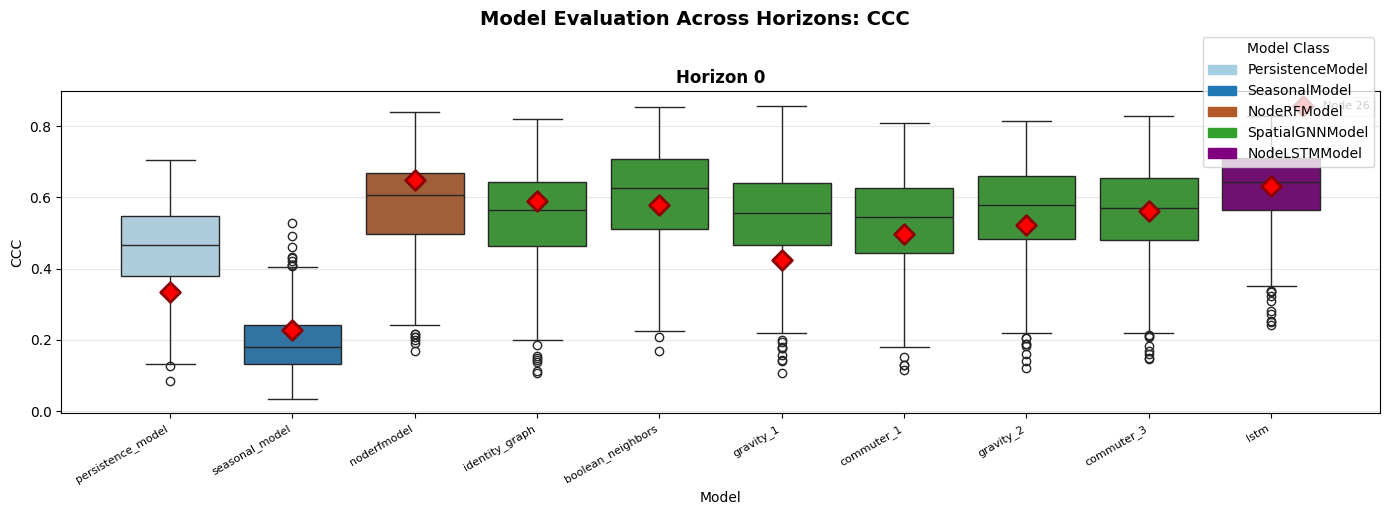

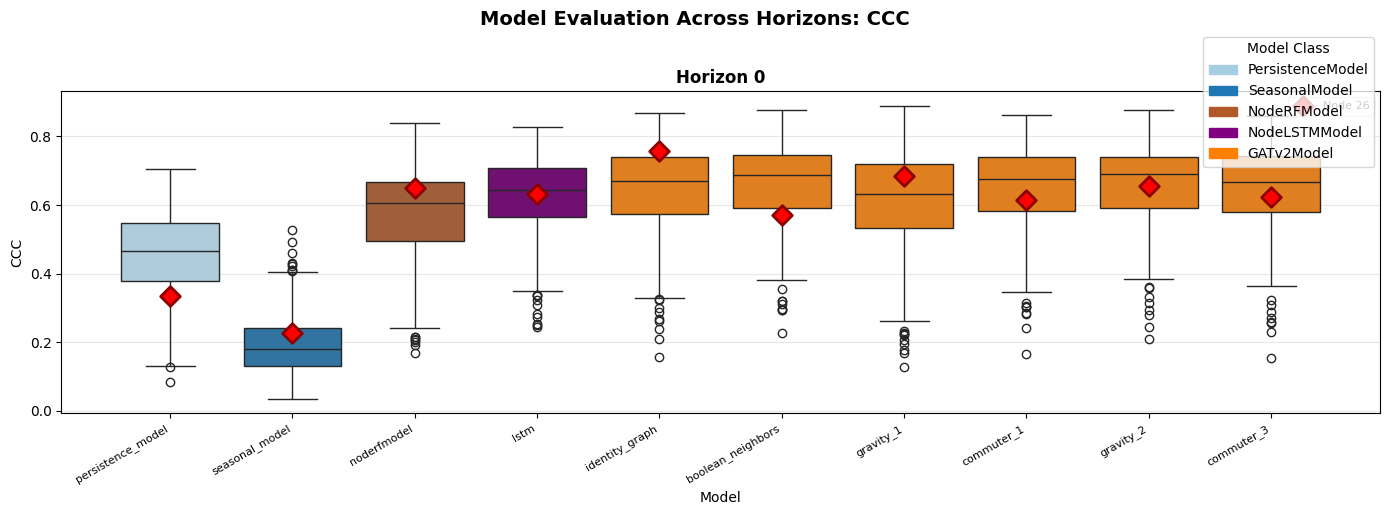

In [16]:
from srcv2.evaluation import Evaluator
evaluation_spatial = Evaluator([persistence, sm, rf, spatial_model1, spatial_model2, spatial_model3, spatial_model4, spatial_model5, spatial_model6, lstm])
evaluation_spatial.add_evaluation(0, 'train')
evaluation_spatial.plotter.plot_metric_horizons_separate('ccc', horizons = [0], dataset = 'train', plot_type='box', highlight_node=26)

evaluation_spatialtemporal = Evaluator([persistence, sm, rf, lstm,spatiotemporal_model1,spatiotemporal_model2,spatiotemporal_model3,spatiotemporal_model4,spatiotemporal_model5,spatiotemporal_model6])
evaluation_spatialtemporal.add_evaluation(0, 'train')
evaluation_spatialtemporal.plotter.plot_metric_horizons_separate('ccc', horizons = [0], dataset = 'train', plot_type='box', highlight_node=26)

computing metrics:   0%|                                                                                | 0/5 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:08<00:00,  1.67s/it]
/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:08<00:00,  1.74s/it]
/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


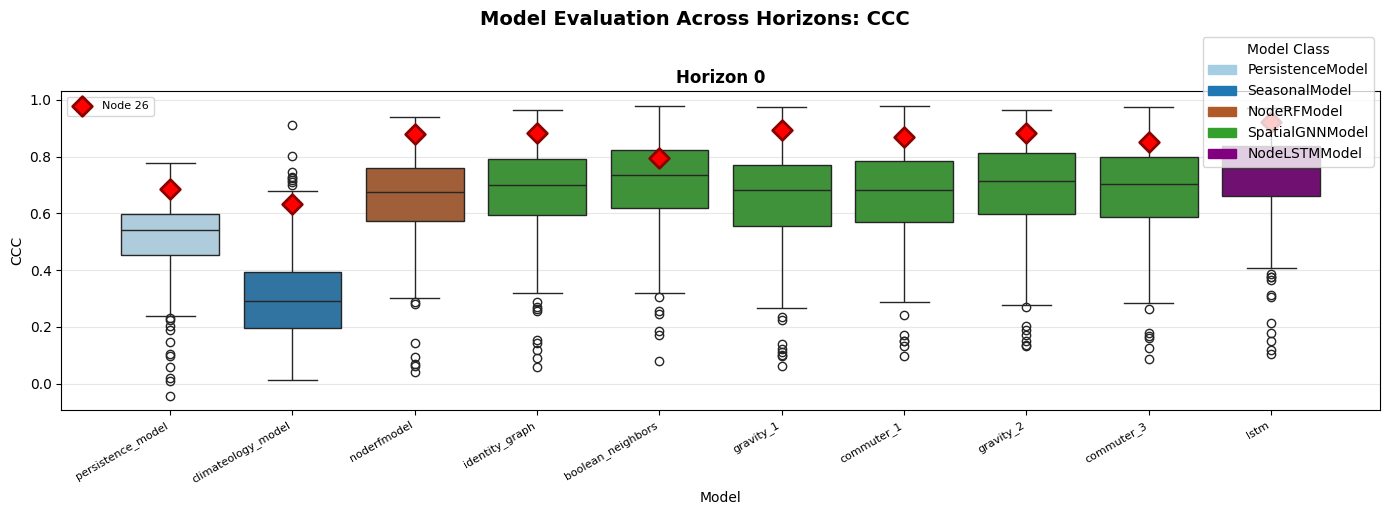

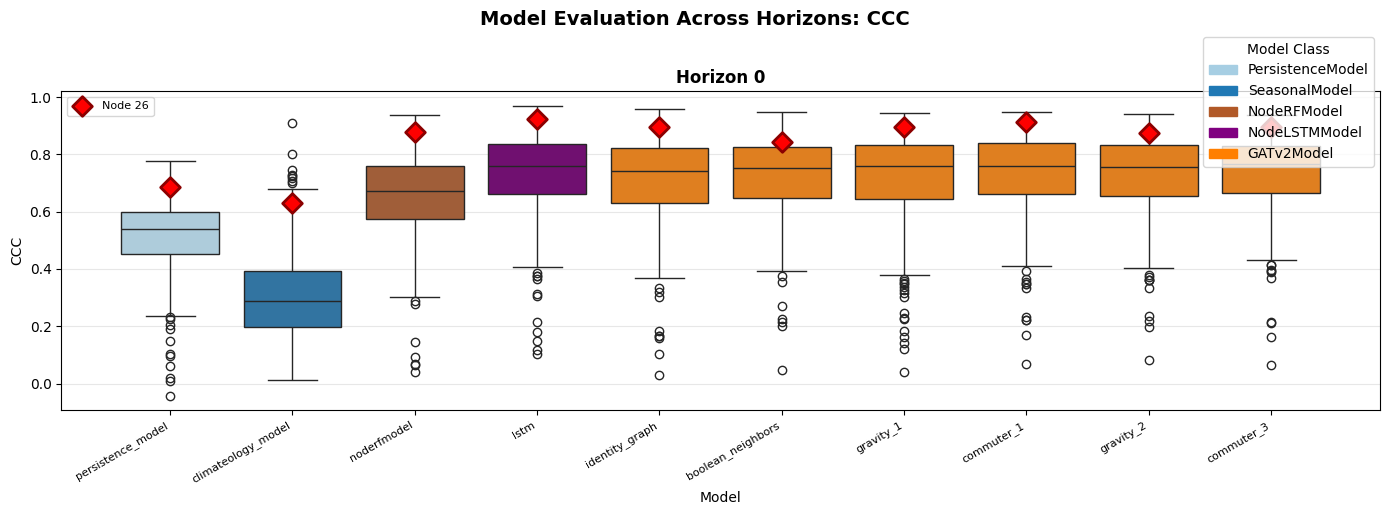

In [30]:
from srcv2.evaluation import Evaluator
sm.name = 'Climateology_model'
evaluation_spatial = Evaluator([persistence, sm, rf, spatial_model1, spatial_model2, spatial_model3, spatial_model4, spatial_model5, spatial_model6, lstm])
evaluation_spatial.add_evaluation(0, 'test')
evaluation_spatial.plotter.plot_metric_horizons_separate('ccc', horizons = [0], dataset = 'test', plot_type='box', highlight_node=26)

evaluation_spatialtemporal = Evaluator([persistence, sm, rf, lstm,spatiotemporal_model1,spatiotemporal_model2,spatiotemporal_model3,spatiotemporal_model4,spatiotemporal_model5,spatiotemporal_model6])
evaluation_spatialtemporal.add_evaluation(0, 'test')
evaluation_spatialtemporal.plotter.plot_metric_horizons_separate('ccc', horizons = [0], dataset = 'test', plot_type='box', highlight_node=26)

/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


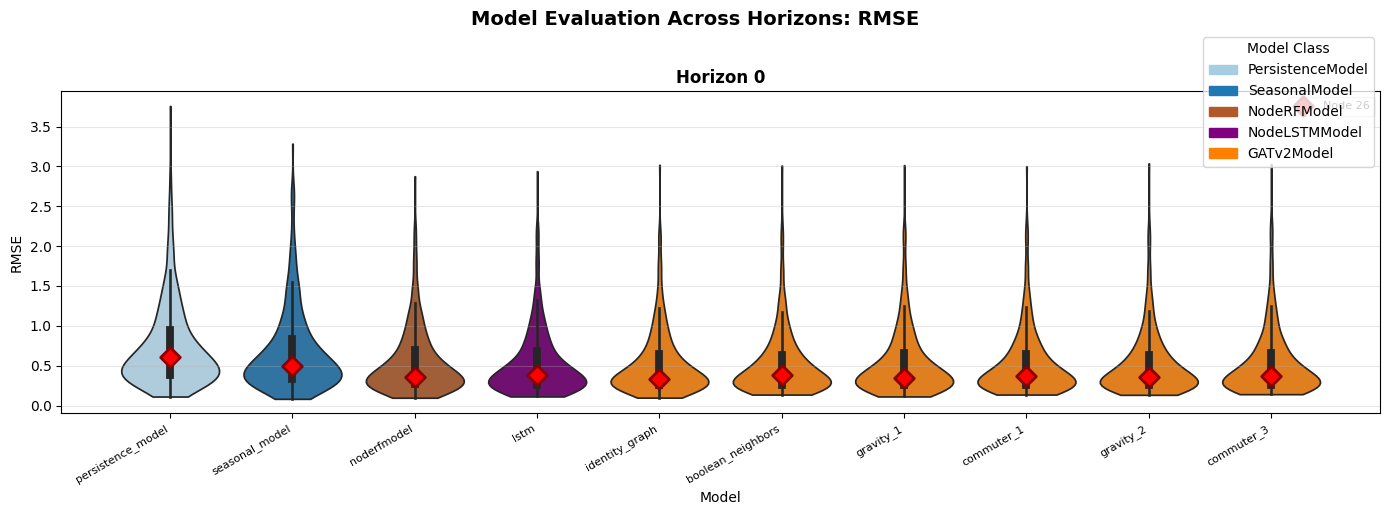

In [28]:
# evaluation_spatialtemporal.add_evaluation(0, 'train')
evaluation_spatialtemporal.plotter.plot_metric_horizons_separate('rmse', horizons = [0], dataset = 'train', plot_type='violin', highlight_node=26)


/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


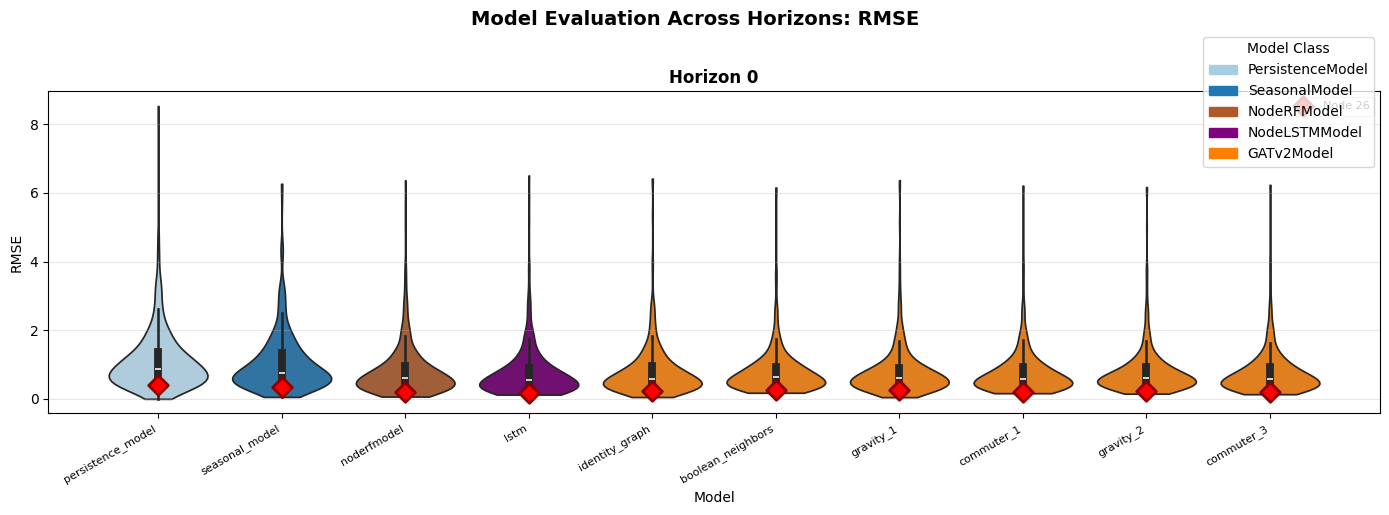

In [29]:
# evaluation_spatialtemporal.add_evaluation(0, 'test')
evaluation_spatialtemporal.plotter.plot_metric_horizons_separate('rmse', horizons = [0], dataset = 'test', plot_type='violin', highlight_node=26)


/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


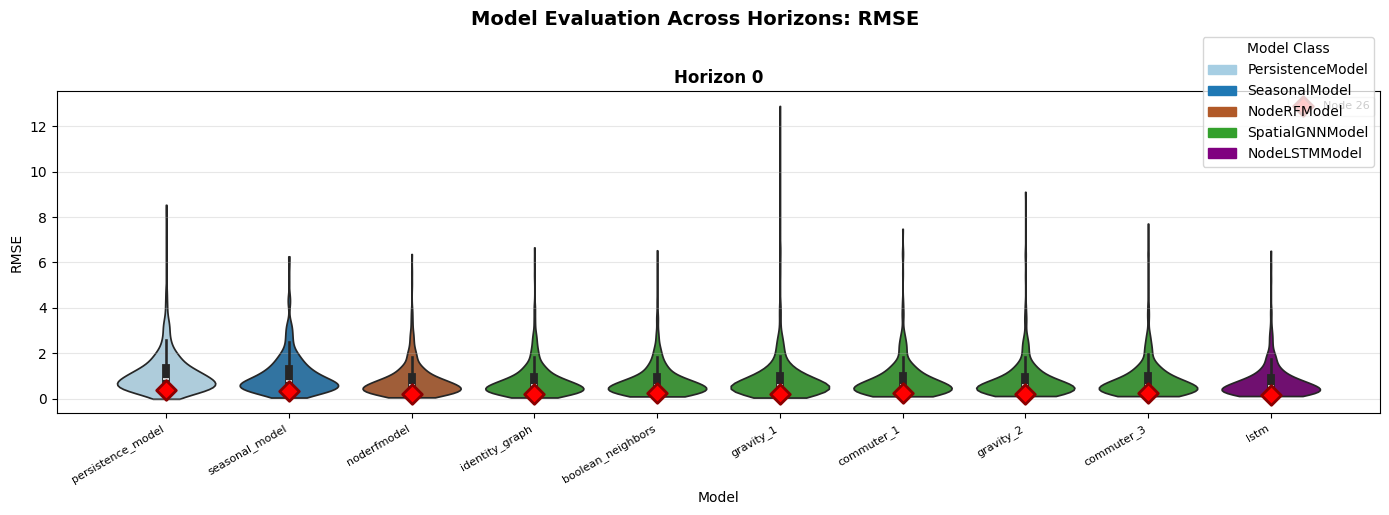

In [20]:
evaluation_spatial.plotter.plot_metric_horizons_separate('rmse', horizons = [0], dataset = 'test', plot_type='violin', highlight_node=26)


computing metrics:   0%|                                                                                | 0/5 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:09<00:00,  1.87s/it]
/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


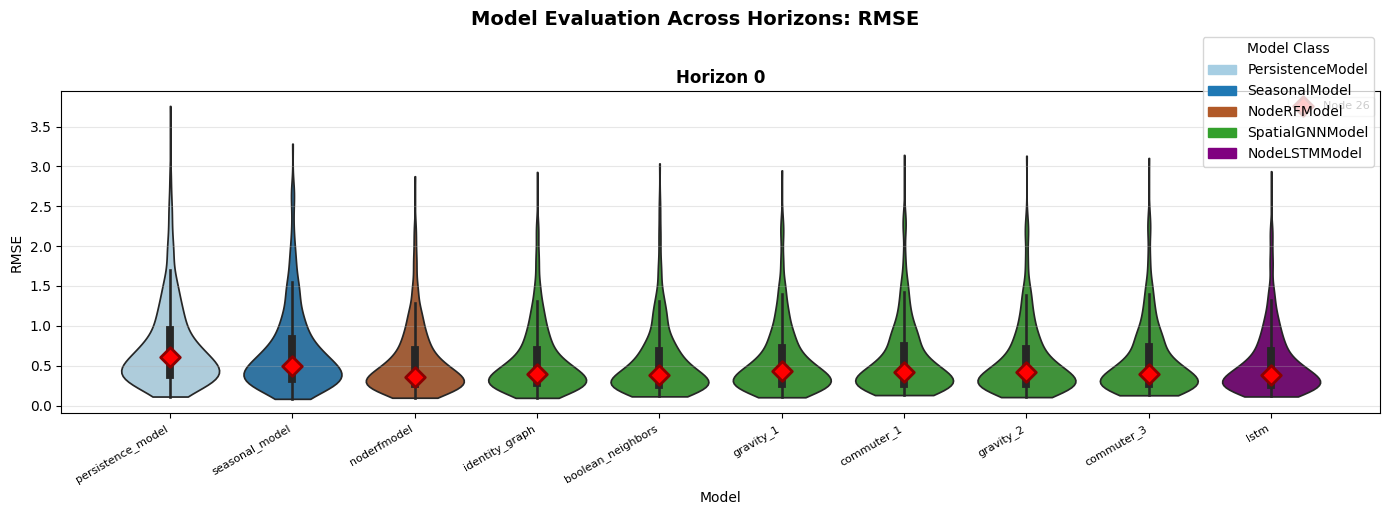

In [25]:
evaluation_spatial.add_evaluation(horizon = 0 ,dataset = 'train')
evaluation_spatial.plotter.plot_metric_horizons_separate('rmse', horizons = [0], dataset = 'train', plot_type='violin', highlight_node=26)


In [10]:
# from typing import Union, List, Literal, Union, Optional, Dict
# import pandas as pd
# from tqdm import tqdm 

# from src.evaluation.metrics import Metrics
# from src.utils.textformatting import align
# from src.UPDATED_models.base.basemodel import BaseModelUPDATED
# from src.UPDATED_evaluation.evaluationplotter import EvaluationPlotter
# from src.UPDATED_evaluation.containers import PredictionCompilation, MetricCompilation


# class Evaluator:

#     """
#     Evaluates models on spatiotemporal epidemioligal predictions

#     Examples:
#     --------
#     >>> evaluator = Evaluator([ml1, ml2])
#     >>> evaluator.add_evaluation()
#     >>> evaluator.plotter.plot_metric("ccc", plot_type = "map")

#     See Also:
#     --------
#     EvaluationPlotter
#     Metrics
#     """

#     def __init__(self, models: Union[BaseModelUPDATED, List[BaseModelUPDATED]]):
#         models_list             = models if isinstance(models, list) else [models]
#         self.evaluated_models   = {ml.clean_name: ml for ml in models_list}
        
#         # Column names
#         self.target_col     = 'target'
#         self.pred_col       = 'pred'
#         self.id_col         = 'node'
#         self.temporal_col   = 'timestamp'
        
#         # Storage
#         self.evaluation_entries: Dict[str, pd.DataFrame]         = {}
#         self.metrics = ['mse','rmse','spearman_corr','ccc','node_smape']


#         self.plotter = EvaluationPlotter(self)

#         self.prediction_compilations = PredictionCompilation()
#         self.metric_compilations     = MetricCompilation()
            
#     def add_evaluation(self, 
#                        horizon:     int  = 0,
#                        dataset:     Literal['train', 'val', 'test'] = 'test') -> 'Evaluator':
#         """
#         Add evaluation entry for specified horizon.
        
#         Parameters:
#         -----------
#         horizon : int
#             Prediction horizon
#         dataset : str
#             Which dataset to evaluate
#         """
#         compilation_preds   = self._compile_predictions(horizon, dataset)
#         self.prediction_compilations.add_horizon(compilation_preds, f'horizon_{horizon}', dataset)

#         # compute metrics
#         compilation_metrics = self._compile_metrics(horizon, dataset)
#         self.metric_compilations.add_horizon(compilation_metrics, f'horizon_{horizon}', dataset)

#         return self

#     def _get_metrics_calculator(self, model: BaseModelUPDATED) -> Metrics:
#         """Create metrics calculator with model's graph structure."""
#         edge_index  = getattr(model.dataloadermanager, 'edge_index', None)
#         edge_weight = getattr(model.dataloadermanager, 'edge_weight', None)
        
#         return Metrics(
#             target_col  = self.target_col,
#             pred_col    = self.pred_col,
#             id_col      = self.id_col,
#             temporal_col= self.temporal_col,
#             edge_index  = edge_index,
#             edge_weight = edge_weight
#         )

#     def _compile_metrics(self, horizon, dataset) -> dict:
#         metrics_dict = {}
#         for metric_name in tqdm(self.metrics, desc = 'computing metrics'):
#             metric_df = self._compute_all_models_metric(
#                 metric_name, horizon, dataset
#             )
#             metrics_dict[metric_name] = metric_df
#         return metrics_dict

#     def _compile_predictions(self, horizon, dataset) -> pd.DataFrame:
#         predictions_compilation = None

#         for name, model in self.evaluated_models.items():
#             model_predictions = model.predictions.get_preds(dataset).get_original(horizon).rename(columns = {'pred' : f'pred_{name}'})
#             if predictions_compilation is None:
#                 predictions_compilation= model_predictions
#             else:
#                 predictions_compilation = pd.merge(predictions_compilation, model_predictions[['timestamp','node',f'pred_{name}']], on = ['timestamp','node'])

#         if predictions_compilation is None:
#             raise IndexError(f'predictions_compilation is invalid')        
        
#         return predictions_compilation

#     def _compute_standard_metric(self, df: pd.DataFrame, 
#                                  metric_name: str, 
#                                  model: BaseModelUPDATED) -> pd.DataFrame:
#         """Compute standard metric per node using groupby."""
#         calculator  = self._get_metrics_calculator(model)
#         metric_func = getattr(calculator, metric_name)
        
#         # Drop id_col before groupby to avoid the warning
#         df_for_grouping = df.drop(columns=[self.id_col])
        
#         return (
#             df_for_grouping
#             .groupby(df[self.id_col])  # Group by the original column
#             .apply(metric_func)
#             .rename(metric_name)
#             .reset_index()
#         )
   
#     def _compute_all_models_metric(self, 
#                                    metric_name: str,
#                                    horizon,
#                                    dataset) -> pd.DataFrame:
#         """Compute specified metric for all models."""
#         metric_df = None
        
#         for name, model in self.evaluated_models.items():
#             model_predictions = model.predictions.get_preds(dataset).get_original(horizon)

#             # Route to appropriate computation method
#             result = self._compute_standard_metric(model_predictions, metric_name, model)

#             result.columns.values[-1] = name
            
#             if metric_df is None:
#                 metric_df = result
#             else:
#                 metric_df = pd.merge(metric_df, result, on=[self.id_col])

#         if metric_df is None:
#             raise ValueError('No metric dataframe found. Something is wrong in the evaluation datasets')
                
#         return metric_df

computing metrics:   0%|                                                                                                                                                                | 0/5 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.46s/it]
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


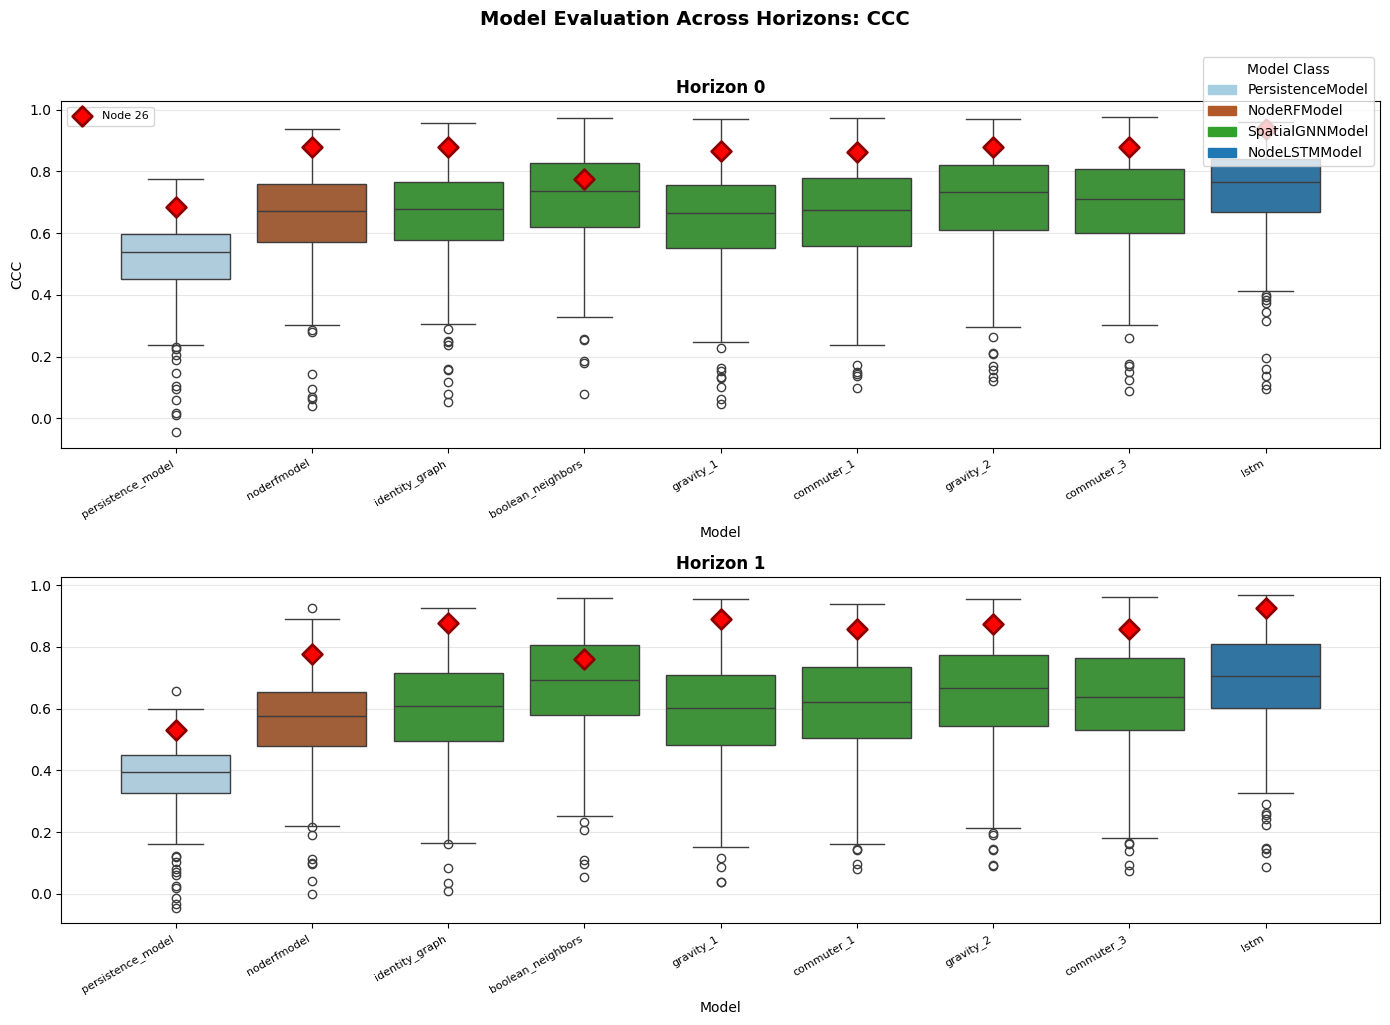

In [11]:
evaluation_spatialmodels = Evaluator([persistence, rf, spatial_model1, spatial_model2, spatial_model3, spatial_model4, spatial_model5, spatial_model6, lstm])
evaluation_spatialmodels.add_evaluation(0, 'test')
evaluation_spatialmodels.add_evaluation(1, 'test')
evaluation_spatialmodels.plotter.plot_metric_horizons_separate('ccc', horizons = [0,1], plot_type='box', highlight_node=26)

In [12]:
# lstm, boolean neighbors (spatial and spatiotemporal), commuter 3 (twice)

spatiotemporal_model2.name = 'GATv2-boolean_neighbors'
spatiotemporal_model6.name = 'GATv2-commuter_3'

spatial_model1.name = 'GCN-identity_graph'
spatial_model2.name = 'GCN-boolean_neighbors'
spatial_model6.name = 'GCN-commuter_3'

models = [spatial_model1,spatial_model6, spatiotemporal_model6]

best_evaluation = Evaluator(models)
best_evaluation.add_evaluation(0, 'test')
best_evaluation.add_evaluation(1, 'test')
ccc                     = best_evaluation.metric_compilations.get_compilation('horizon_0','test')['ccc'].dropna()
n = 3

ccc['mean']             = ccc.iloc[:, 1:].mean(axis=1)
ccc_sorted              = ccc.sort_values(by = 'mean')
min_nodes, max_nodes    = list(ccc_sorted[0:n]['node'].unique()),list(ccc_sorted[-n:]['node'].unique())

lstm_color = lstm.model_color
gcn_color  = spatial_model1.model_color
gatv2_color= spatiotemporal_model1.model_color

computing metrics:   0%|                                                                                                                                                                | 0/5 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.02it/s]
/local/job_22673904/ipykernel_3223629/4131823916.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ccc['mean']             = ccc.iloc[:, 1:].mean(axis=1)


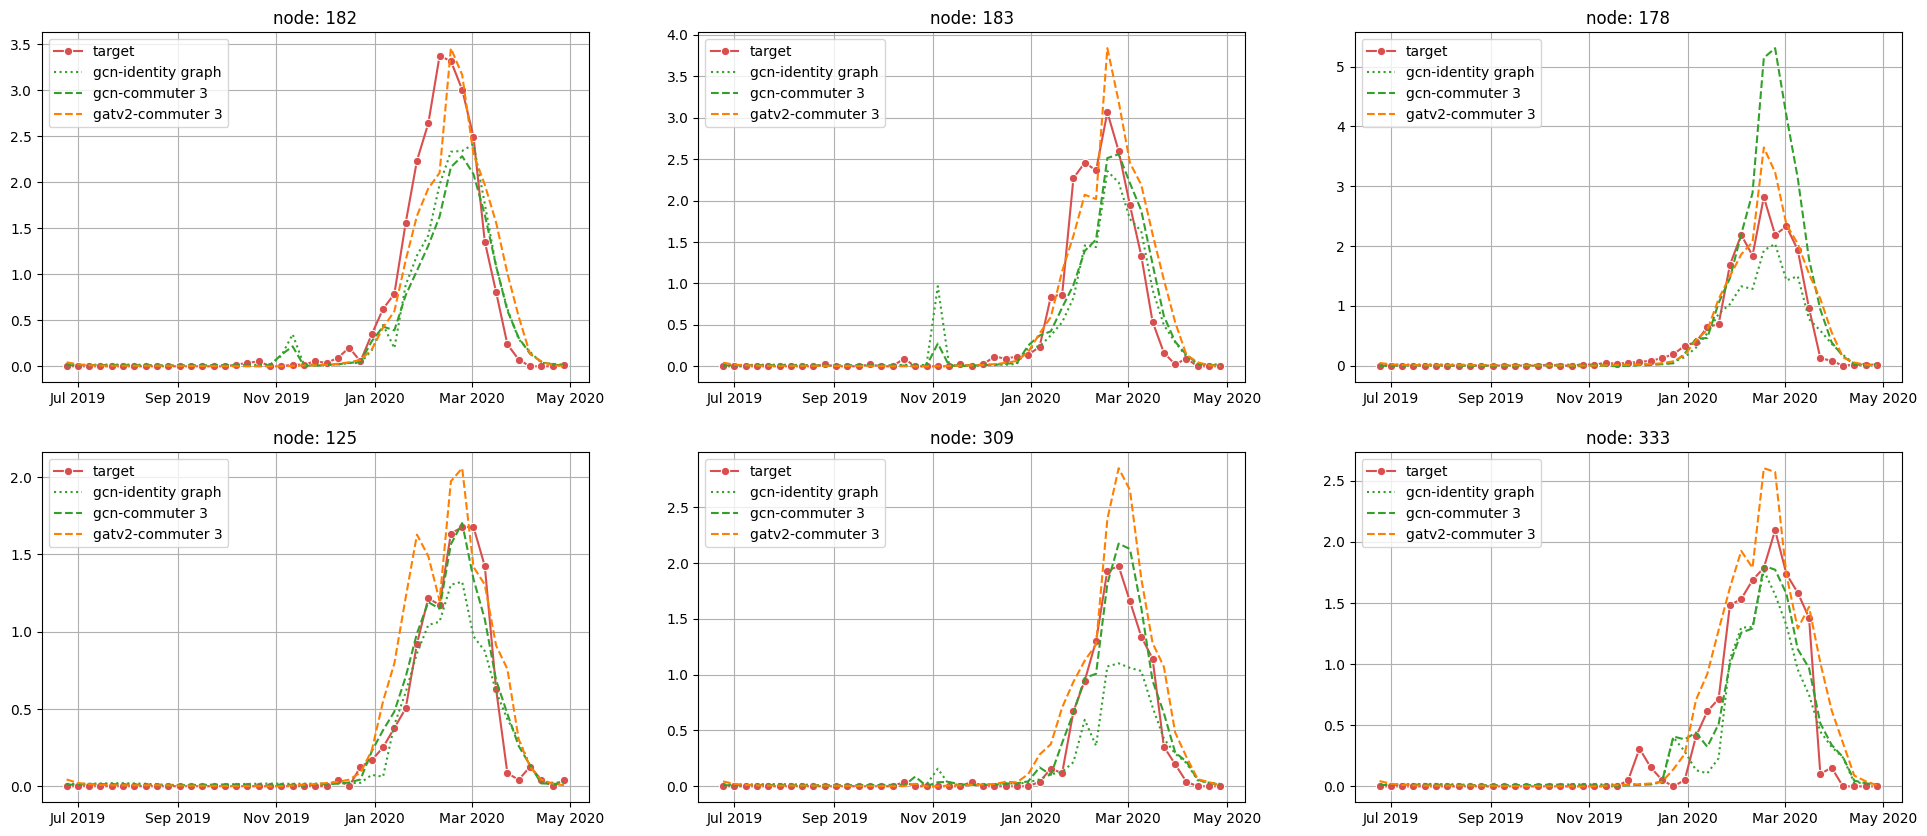

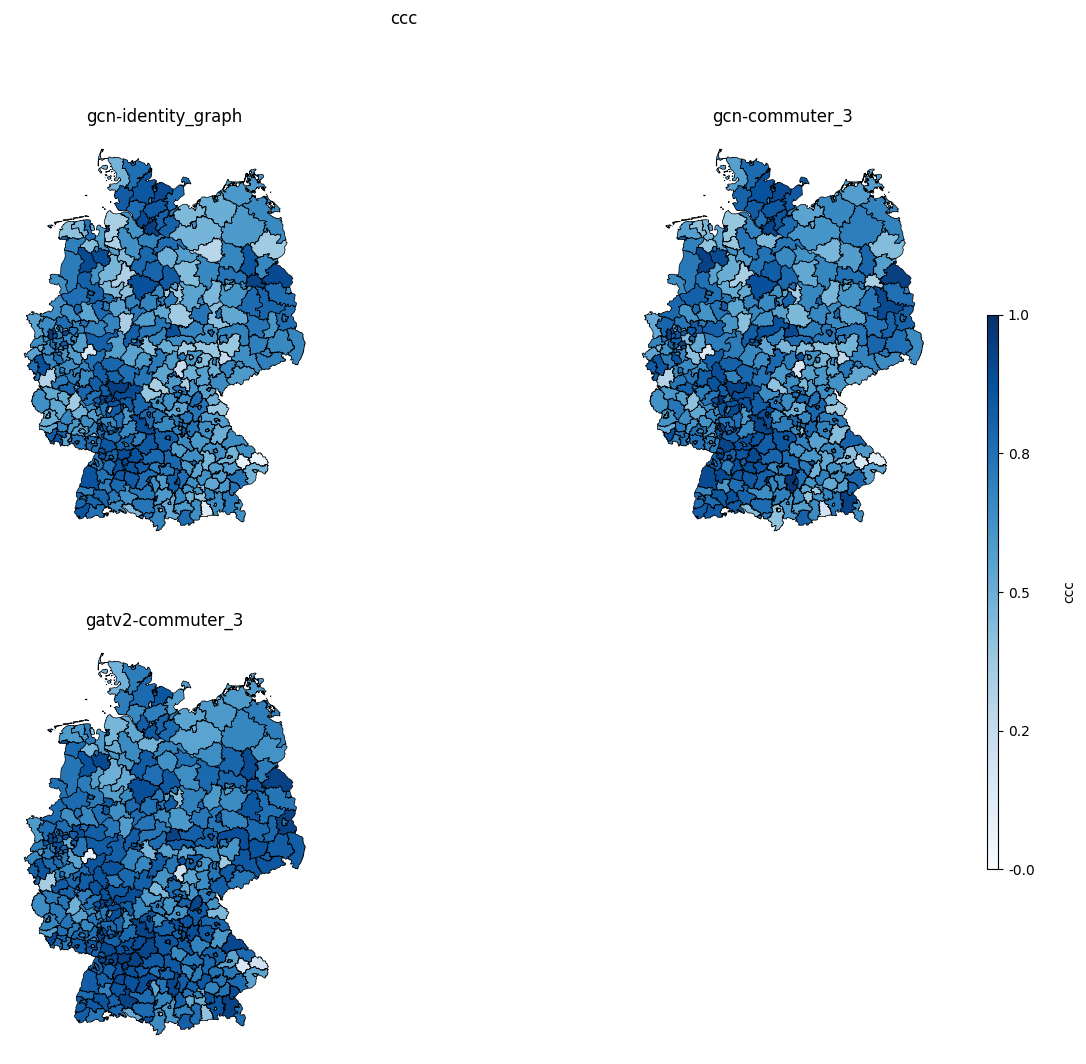

In [13]:
import matplotlib.pyplot as plt 
import seaborn as sns
from src.utils import testcolor
import matplotlib.dates as mdates




best_evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0', plot_type = 'map')

Text(0.5, 1.0, 'node: 178')

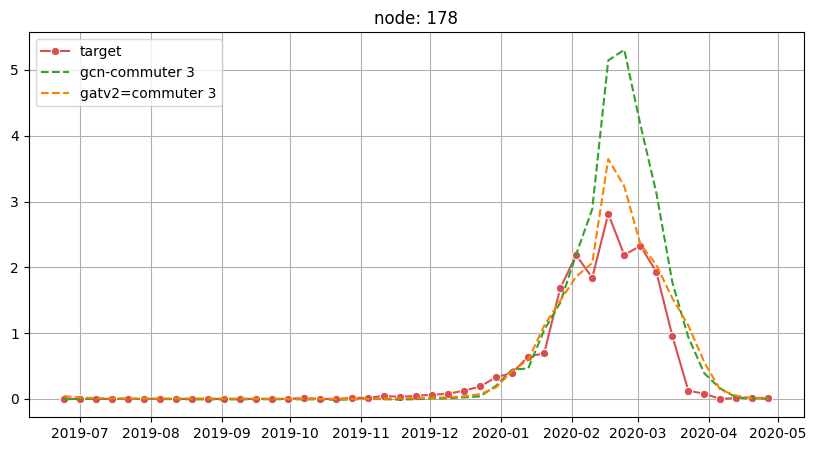

In [14]:
fig, ax = plt.subplots(1,1, figsize = (10,5))
node_id = 178
node_data = preds_compi[preds_compi['node'] == node_id]
# ax        = axes[idx]
sns.lineplot(node_data, x = 'timestamp', y = 'target',                          color = testcolor,          label = 'target',               marker = 'o',       ax = ax)
  
sns.lineplot(node_data, x = 'timestamp', y = 'pred_gcn-commuter_3',             color = gcn_color, linestyle = "--",       label = 'gcn-commuter 3',                   ax = ax)     
sns.lineplot(node_data, x = 'timestamp', y = 'pred_gatv2-commuter_3',           color = gatv2_color, linestyle = "--",       label = 'gatv2=commuter 3',                 ax = ax)   
ax.grid()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f'node: {node_id}')     

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.57s/it]
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


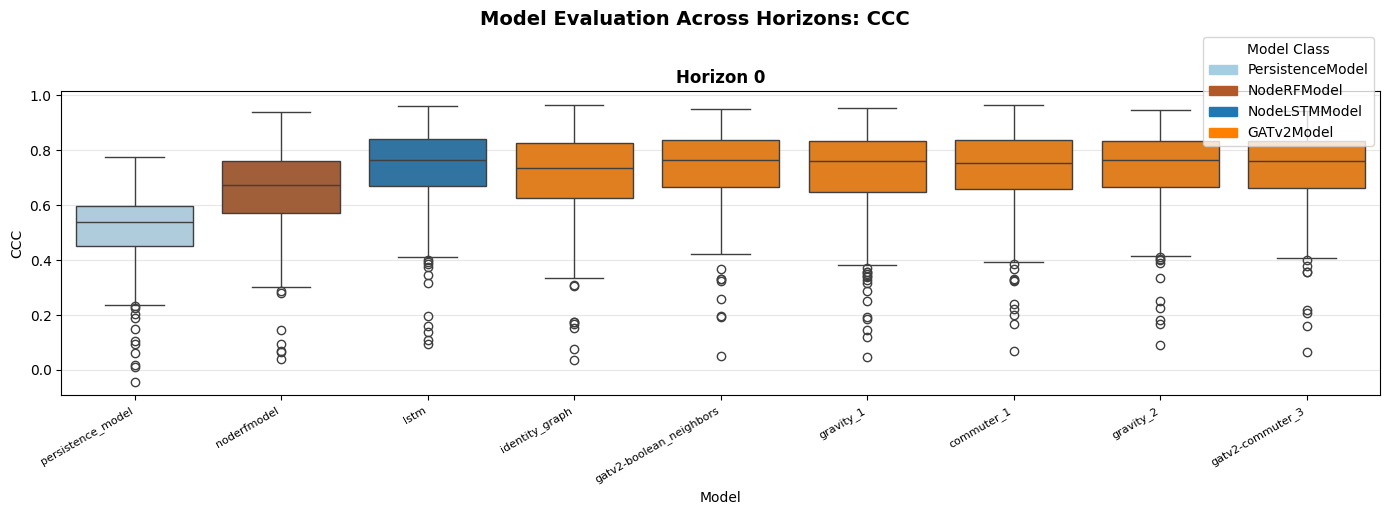

In [23]:
from src.UPDATED_evaluation.evaluator import Evaluator
spatiotemporal_evaluation = Evaluator([persistence, rf, lstm, spatiotemporal_model1, spatiotemporal_model2, spatiotemporal_model3, spatiotemporal_model4, spatiotemporal_model5, spatiotemporal_model6])
spatiotemporal_evaluation.add_evaluation(0, 'test')
# spatiotemporal_evaluation.add_evaluation(1, 'test')

spatiotemporal_evaluation.plotter.plot_metric_horizons_separate('ccc', horizons = [0], plot_type='box')

/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


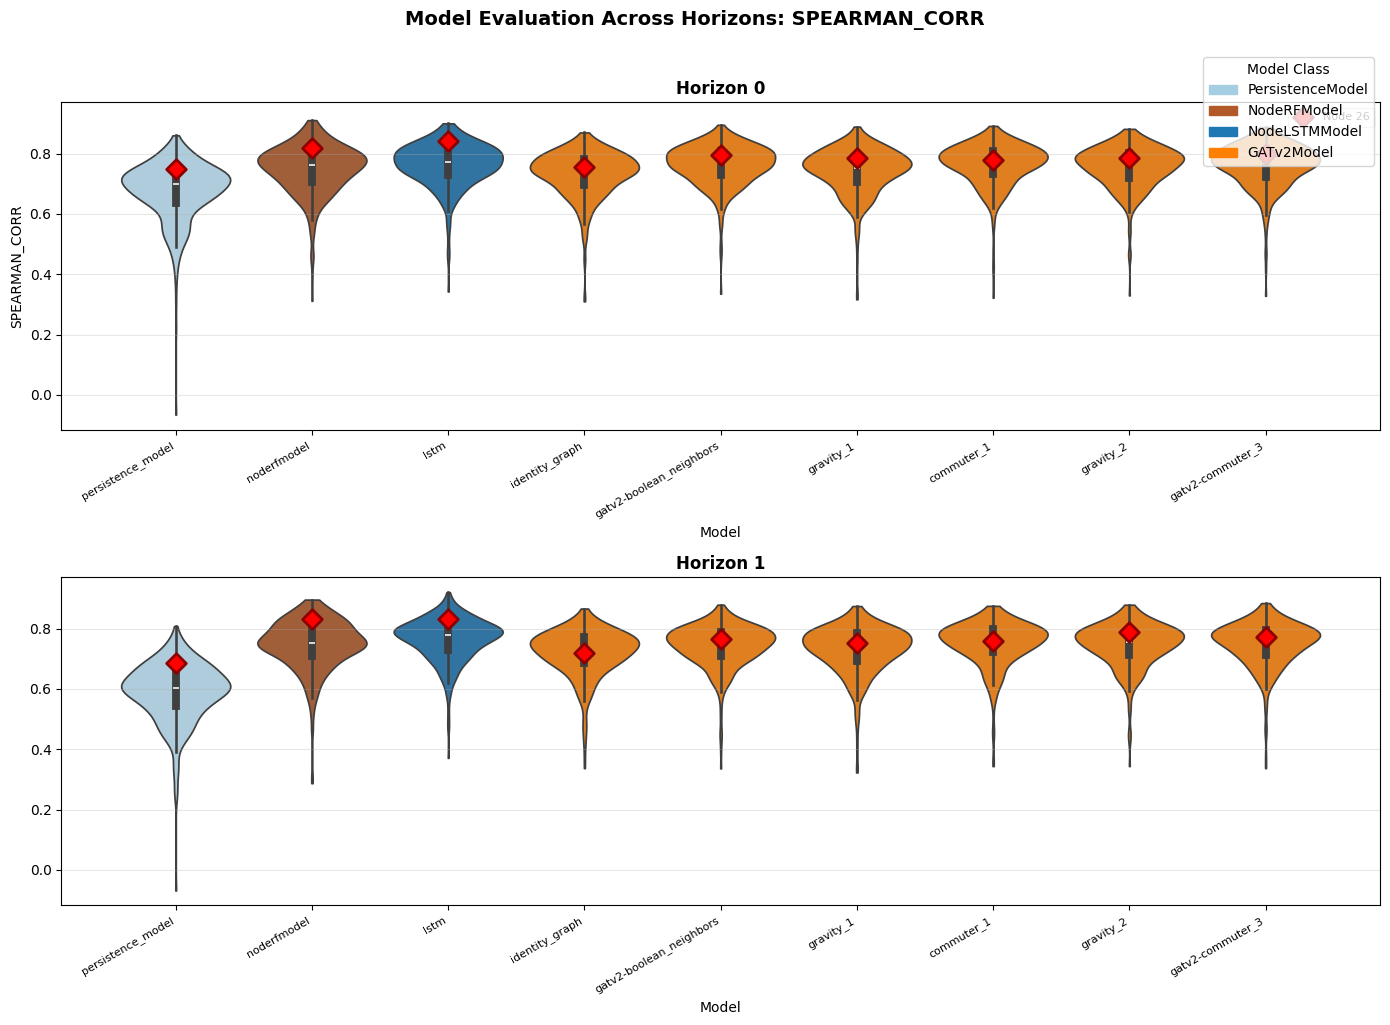

In [19]:
spatiotemporal_evaluation.plotter.plot_metric_horizons_separate('spearman_corr', horizons = [0,1], plot_type='violin', highlight_node=26)

In [ ]:
# show timeseries of the 3 best and 3 worst nodes